# MDI3003 Lab 04 – Dataset (Bank Marketing)
#### Link - https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Environment Setup and Imports

In [51]:
# Import standard libraries
import os
import sys
import json
import hashlib
import warnings
import joblib
import platform
import datetime
import subprocess
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn components
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    KBinsDiscretizer,
    OrdinalEncoder,
    FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, CategoricalNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Other utilities
import joblib
import warnings
warnings.filterwarnings('ignore')

# Print versions
print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("sklearn version:", sklearn.__version__)
print("seaborn version:", sns.__version__)
print("matplotlib version:", plt.matplotlib.__version__)

# -----------------------------------------------------------------------------
# Create output directory structure
# -----------------------------------------------------------------------------
base_dir = Path.cwd().parent
dirs = {
    "data_raw": os.path.join(base_dir, "data", "raw"),
    "data_processed": os.path.join(base_dir, "data", "processed"),
    "reports": os.path.join(base_dir, "reports"),
    "figures": os.path.join(base_dir, "figures"),
    "models": os.path.join(base_dir, "models"),
    "artifacts": os.path.join(base_dir, "artifacts"),
    "results": os.path.join(base_dir, "results"),
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)

print("Directory structure created:")
for name, path in dirs.items():
    print(f"  {name}: {path}")

# -----------------------------------------------------------------------------
# Capture system and library versions to a JSON artifact
# -----------------------------------------------------------------------------
version_info = {
    "timestamp": datetime.datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "libraries": {
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "sklearn": sklearn.__version__,
        "seaborn": sns.__version__,
        "matplotlib": plt.matplotlib.__version__,
        "joblib": joblib.__version__,
    }
}

with open(os.path.join(dirs["artifacts"], "versions.json"), "w") as f:
    json.dump(version_info, f, indent=2)

print("Version info saved to artifacts/versions.json")

Python version: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
pandas version: 2.3.2
numpy version: 2.2.6
sklearn version: 1.7.2
seaborn version: 0.13.2
matplotlib version: 3.10.6
Directory structure created:
  data_raw: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\data\raw
  data_processed: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\data\processed
  reports: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\reports
  figures: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\figures
  models: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models
  artifacts: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\artifacts
  results: c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\results
Version info saved to artifacts/versions.json


## 2. Load Dataset

In [52]:
raw_data_path = os.path.join(dirs["data_processed"], "bank_marketing_output", "bank_marketing_clean.csv")
# Compute SHA-256 checksum of the file
sha256_hash = hashlib.sha256()
with open(raw_data_path, "rb") as f:
    for byte_block in iter(lambda: f.read(4096), b""):
        sha256_hash.update(byte_block)
file_checksum = sha256_hash.hexdigest()
print(f"SHA-256 checksum of raw file: {file_checksum}")

# Save checksum to artifact
with open(os.path.join(dirs["artifacts"], "file_checksum.json"), "w") as f:
    json.dump({"filename": "bank_marketing_clean.csv", "sha256": file_checksum}, f, indent=2)

# Load the dataset as a single DataFrame (no separate train/test files)
df = pd.read_csv(raw_data_path)
print(f"Loaded dataset with shape: {df.shape}")
print("First 3 rows:")
print(df.head(3))
print("\nColumn data types:")
print(df.dtypes)

SHA-256 checksum of raw file: 9d51d79233ad8b098954ad4b22586feae378f0041552adeaeffa3aba7db77faf
Loaded dataset with shape: (45211, 17)
First 3 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   

  contact  day month  duration  campaign  pdays  previous poutcome   y  
0     NaN    5   may       261         1     -1         0      NaN  no  
1     NaN    5   may       151         1     -1         0      NaN  no  
2     NaN    5   may        76         1     -1         0      NaN  no  

Column data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
cam

## 3. Dataset Governance and Provenance Documentation

In [53]:
dataset_card = {
    "name": "Bank Marketing Dataset (UCI)",
    "source_url": "https://archive.ics.uci.edu/dataset/222/bank+marketing",
    "license": "Unknown (UCI public repository)",
    "description": (
        "The data is related to direct marketing campaigns of a Portuguese banking institution. "
        "The classification goal is to predict if the client will subscribe to a term deposit (target 'y')."
    ),
    "record_count": len(df),
    "feature_count": df.shape[1] - 1,  # excluding target
    "target_column": "y",
    "target_classes": sorted(df["y"].unique().tolist()),  # actual values from data
    "id_column": None,  # no explicit customer ID
    "id_surrogate": "row_index",  # we will use row index for traceability only
    "columns": df.columns.tolist(),
    "checksum": file_checksum,
}

print("Dataset Card:")
for k, v in dataset_card.items():
    print(f"  {k}: {v}")

# Save to JSON
with open(os.path.join(dirs["artifacts"], "dataset_card.json"), "w") as f:
    json.dump(dataset_card, f, indent=2)

print("Dataset card saved to artifacts/dataset_card.json")

Dataset Card:
  name: Bank Marketing Dataset (UCI)
  source_url: https://archive.ics.uci.edu/dataset/222/bank+marketing
  license: Unknown (UCI public repository)
  description: The data is related to direct marketing campaigns of a Portuguese banking institution. The classification goal is to predict if the client will subscribe to a term deposit (target 'y').
  record_count: 45211
  feature_count: 16
  target_column: y
  target_classes: ['no', 'yes']
  id_column: None
  id_surrogate: row_index
  columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
  checksum: 9d51d79233ad8b098954ad4b22586feae378f0041552adeaeffa3aba7db77faf
Dataset card saved to artifacts/dataset_card.json


## 4. Label-Provenance and Circularity Audit


In [54]:
# -----------------------------------------------------------------------------
# Check for deterministic/near-deterministic mapping to target
# (same style as reference notebook: test if any column can perfectly predict y)
# -----------------------------------------------------------------------------
print("\n=== Circularity / Label Leakage Audit ===")
target = "y"
leakage_candidates = []

for col in df.columns:
    if col == target:
        continue
    # Check if mapping from col to target is deterministic (one unique y per col value)
    # Also check if target is nearly constant per col value (e.g., 95% agreement)
    # We'll compute the ratio of the most frequent class for each unique value
    # and then average across values.
    grouped = df.groupby(col)[target].value_counts(normalize=True).unstack(fill_value=0)
    if grouped.shape[0] == 0:
        continue
    # For each value, get the max class probability
    max_prob = grouped.max(axis=1)
    avg_max_prob = max_prob.mean()
    if avg_max_prob > 0.95:
        leakage_candidates.append((col, avg_max_prob))

if leakage_candidates:
    print("Potential leakage / near-deterministic mapping detected:")
    for col, prob in leakage_candidates:
        print(f"  {col}: average max class probability = {prob:.3f}")
else:
    print("No obvious deterministic mapping detected.")

# -----------------------------------------------------------------------------
# Manual inspection for known leakage risk: "duration"
# -----------------------------------------------------------------------------
print("\nManual inspection for known leakage risk (duration):")
if "duration" in df.columns:
    print("  Column 'duration' is present. It is the duration of the last contact.")
    print("  This is often considered a post-outcome artifact because duration is")
    print("  only known after the contact is made, and it is strongly correlated")
    print("  with the outcome (longer calls tend to be successful).")
    print("  => We will exclude 'duration' from the feature set to avoid leakage.")
    EXCLUDE_FEATURES = ["duration"]
else:
    EXCLUDE_FEATURES = []

# Also check if there are any other columns that might be post-outcome:
# 'pdays' (days since previous contact) might be okay, but we'll keep it.
# 'poutcome' is previous outcome, which is legitimate.
print("\nColumns that will be excluded from features (leakage):", EXCLUDE_FEATURES)

# Save this decision to artifact
leakage_decision = {
    "excluded_features": EXCLUDE_FEATURES,
    "reason": "duration is a post-contact artifact; excluding to prevent data leakage."
}
with open(os.path.join(dirs["artifacts"], "leakage_decision.json"), "w") as f:
    json.dump(leakage_decision, f, indent=2)


=== Circularity / Label Leakage Audit ===


Potential leakage / near-deterministic mapping detected:
  campaign: average max class probability = 0.969

Manual inspection for known leakage risk (duration):
  Column 'duration' is present. It is the duration of the last contact.
  This is often considered a post-outcome artifact because duration is
  only known after the contact is made, and it is strongly correlated
  with the outcome (longer calls tend to be successful).
  => We will exclude 'duration' from the feature set to avoid leakage.

Columns that will be excluded from features (leakage): ['duration']


## 5. Identifier Handling


In [55]:
# -----------------------------------------------------------------------------
# Identifier handling: confirm no personal identifiers
# -----------------------------------------------------------------------------
print("\n=== Identifier Audit ===")
# Check columns for common identifier patterns
identifiers = ["id", "customer", "client", "name", "email", "phone", "address"]
found_ids = [col for col in df.columns if any(id_str in col.lower() for id_str in identifiers)]
if found_ids:
    print("Potential identifier columns found:", found_ids)
else:
    print("No obvious personal identifier columns found.")
print("We will use row_index as a surrogate ID for traceability only, and never as a feature.")

# Create a surrogate index column for traceability (won't be used in modeling)
df["row_index"] = df.index
print("Surrogate 'row_index' added (for reference only).")


=== Identifier Audit ===
No obvious personal identifier columns found.
We will use row_index as a surrogate ID for traceability only, and never as a feature.
Surrogate 'row_index' added (for reference only).


## 6. Comprehensive EDA


### 6.1 Data Quality Audit


In [56]:
print("\n=== Data Quality Audit ===")
# Build a summary DataFrame
audit = []
for col in df.columns:
    dtype = df[col].dtype
    missing_count = df[col].isna().sum()
    missing_pct = missing_count / len(df) * 100
    unique_count = df[col].nunique()
    if pd.api.types.is_numeric_dtype(dtype):
        min_val = df[col].min()
        max_val = df[col].max()
        mean_val = df[col].mean()
        std_val = df[col].std()
    else:
        min_val = max_val = mean_val = std_val = None
    audit.append({
        "column": col,
        "dtype": dtype,
        "missing_count": missing_count,
        "missing_pct": missing_pct,
        "unique_count": unique_count,
        "min": min_val,
        "max": max_val,
        "mean": mean_val,
        "std": std_val
    })

audit_df = pd.DataFrame(audit)
print(audit_df)

# Save to CSV
audit_df.to_csv(os.path.join(dirs["reports"], "data_quality_audit.csv"), index=False)
print("Audit table saved to reports/data_quality_audit.csv")


=== Data Quality Audit ===


       column   dtype  missing_count  missing_pct  unique_count     min  \
0         age   int64              0     0.000000            77    18.0   
1         job  object            288     0.637013            11     NaN   
2     marital  object              0     0.000000             3     NaN   
3   education  object           1857     4.107407             3     NaN   
4     default  object              0     0.000000             2     NaN   
5     balance   int64              0     0.000000          7168 -8019.0   
6     housing  object              0     0.000000             2     NaN   
7        loan  object              0     0.000000             2     NaN   
8     contact  object          13020    28.798301             2     NaN   
9         day   int64              0     0.000000            31     1.0   
10      month  object              0     0.000000            12     NaN   
11   duration   int64              0     0.000000          1573     0.0   
12   campaign   int64    

### 6.2 Missingness Analysis (including "unknown" codes)


In [57]:
print("\n=== Missingness and Unknown Value Analysis ===")
# First, check NaN
nan_counts = df.isna().sum()
print("NaN counts per column:")
print(nan_counts[nan_counts > 0] if any(nan_counts > 0) else "No NaN values found.")

# Now check for categorical columns that may contain "unknown" as a category
unknown_vals = ["unknown", "Unknown", "UNKNOWN", "none", "None", "NONE", "NA", "na"]
unknown_summary = {}
for col in df.select_dtypes(include=["object", "category"]).columns:
    # Count rows with values in unknown_vals (case-insensitive)
    mask = df[col].astype(str).str.lower().isin([v.lower() for v in unknown_vals])
    count = mask.sum()
    if count > 0:
        unknown_summary[col] = count

if unknown_summary:
    print("Columns with 'unknown' or similar placeholders:")
    for col, cnt in unknown_summary.items():
        print(f"  {col}: {cnt} rows ({cnt/len(df)*100:.2f}%)")
else:
    print("No explicit 'unknown' placeholders found in categorical columns.")

# Save missingness report
missing_report = {
    "nan_counts": nan_counts[nan_counts > 0].to_dict(),
    "unknown_counts": unknown_summary
}
with open(os.path.join(dirs["reports"], "missingness_report.json"), "w") as f:
    json.dump(missing_report, f, indent=2)
print("Missingness report saved to reports/missingness_report.json")


=== Missingness and Unknown Value Analysis ===
NaN counts per column:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64
No explicit 'unknown' placeholders found in categorical columns.
Missingness report saved to reports/missingness_report.json


### 6.3 Class Distribution Audit (Imbalance)


In [58]:
print("\n=== Target Class Distribution ===")
target_counts = df["y"].value_counts()
target_pcts = df["y"].value_counts(normalize=True) * 100
print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_pcts)

# Compute imbalance ratio
majority = target_counts.max()
minority = target_counts.min()
ratio = majority / minority
print(f"\nImbalance ratio (majority/minority): {ratio:.2f} : 1")
print(f"Minority class proportion: {target_pcts.min():.2f}%")
print("This is a significant imbalance. Accuracy will be misleading; macro F1 will be our primary metric.")

# Save class distribution
class_dist = {
    "counts": target_counts.to_dict(),
    "percentages": target_pcts.to_dict(),
    "imbalance_ratio": ratio
}
with open(os.path.join(dirs["reports"], "class_distribution.json"), "w") as f:
    json.dump(class_dist, f, indent=2)


=== Target Class Distribution ===
Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Imbalance ratio (majority/minority): 7.55 : 1
Minority class proportion: 11.70%
This is a significant imbalance. Accuracy will be misleading; macro F1 will be our primary metric.


### 6.4 Feature Type Taxonomy


In [59]:
# -----------------------------------------------------------------------------
# Feature type taxonomy based on column names and domain knowledge
# -----------------------------------------------------------------------------
print("\n=== Feature Type Taxonomy ===")
# Define groups based on actual column names (from inspection)
all_cols = set(df.columns) - {"y", "row_index"}  # exclude target and surrogate
# Remove excluded features (duration if any)
all_cols = all_cols - set(EXCLUDE_FEATURES)

demographic = ["age", "job", "marital", "education", "default", "balance", "housing", "loan"]
campaign_behavioral = ["contact", "day", "month", "campaign", "pdays", "previous", "poutcome"]

# Check if any columns are unassigned
assigned = set(demographic) | set(campaign_behavioral)
unassigned = all_cols - assigned
if unassigned:
    print("Unassigned columns:", unassigned)

taxonomy = {
    "demographic": [c for c in demographic if c in all_cols],
    "campaign_behavioral": [c for c in campaign_behavioral if c in all_cols],
}
print("Feature taxonomy:")
for group, cols in taxonomy.items():
    print(f"  {group}: {cols}")

# Note: no psychographic or economic context columns in this version.
print("\nNote: This dataset does not include economic context features (emp.var.rate, etc.)")


=== Feature Type Taxonomy ===
Feature taxonomy:
  demographic: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
  campaign_behavioral: ['contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']

Note: This dataset does not include economic context features (emp.var.rate, etc.)


### 6.5 Numerical Feature Distributions



Numerical columns:

 ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


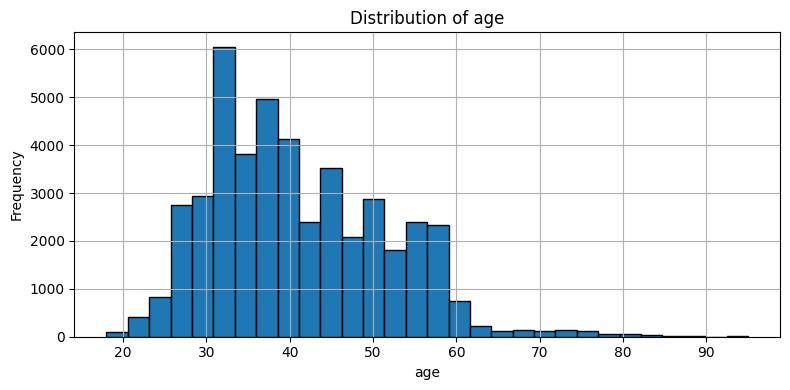

Histogram saved for age


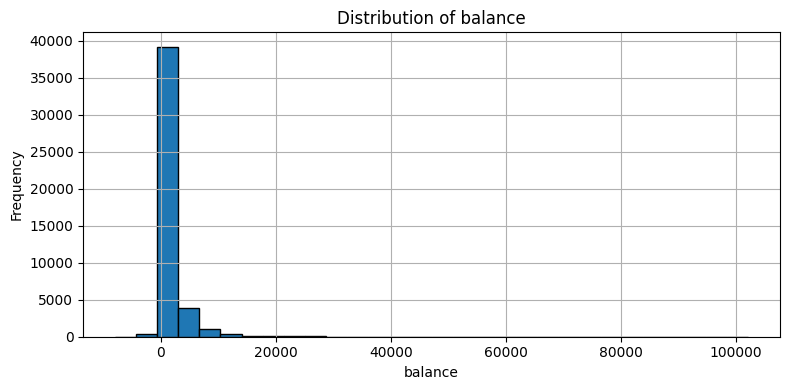

Histogram saved for balance


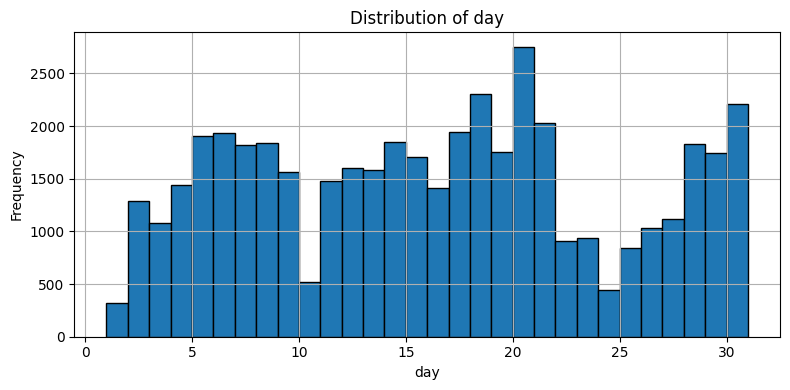

Histogram saved for day


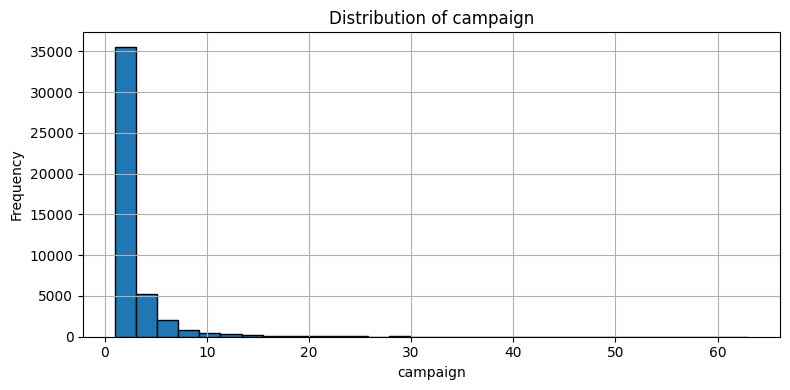

Histogram saved for campaign


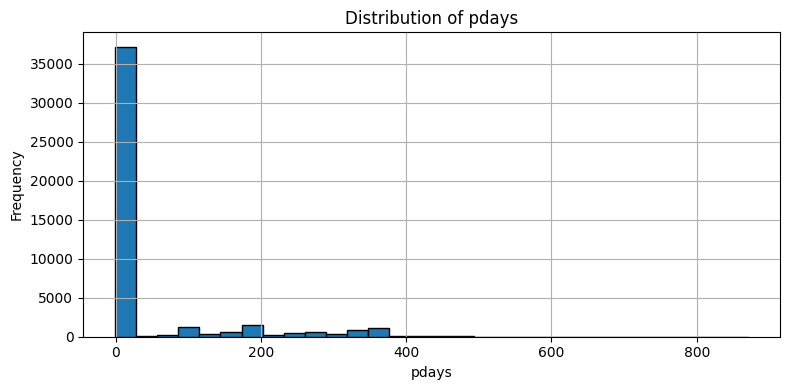

Histogram saved for pdays


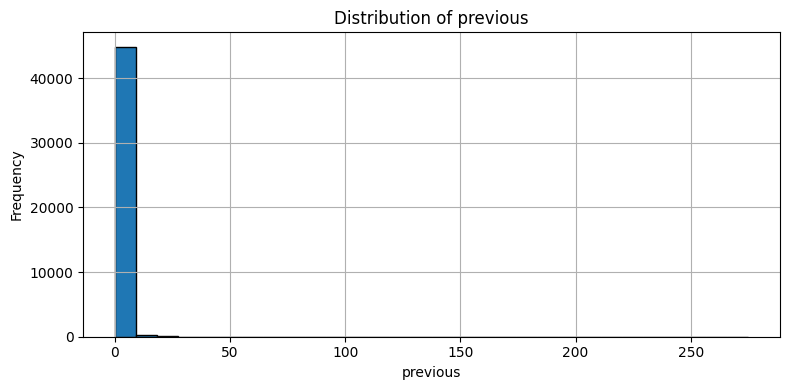

Histogram saved for previous


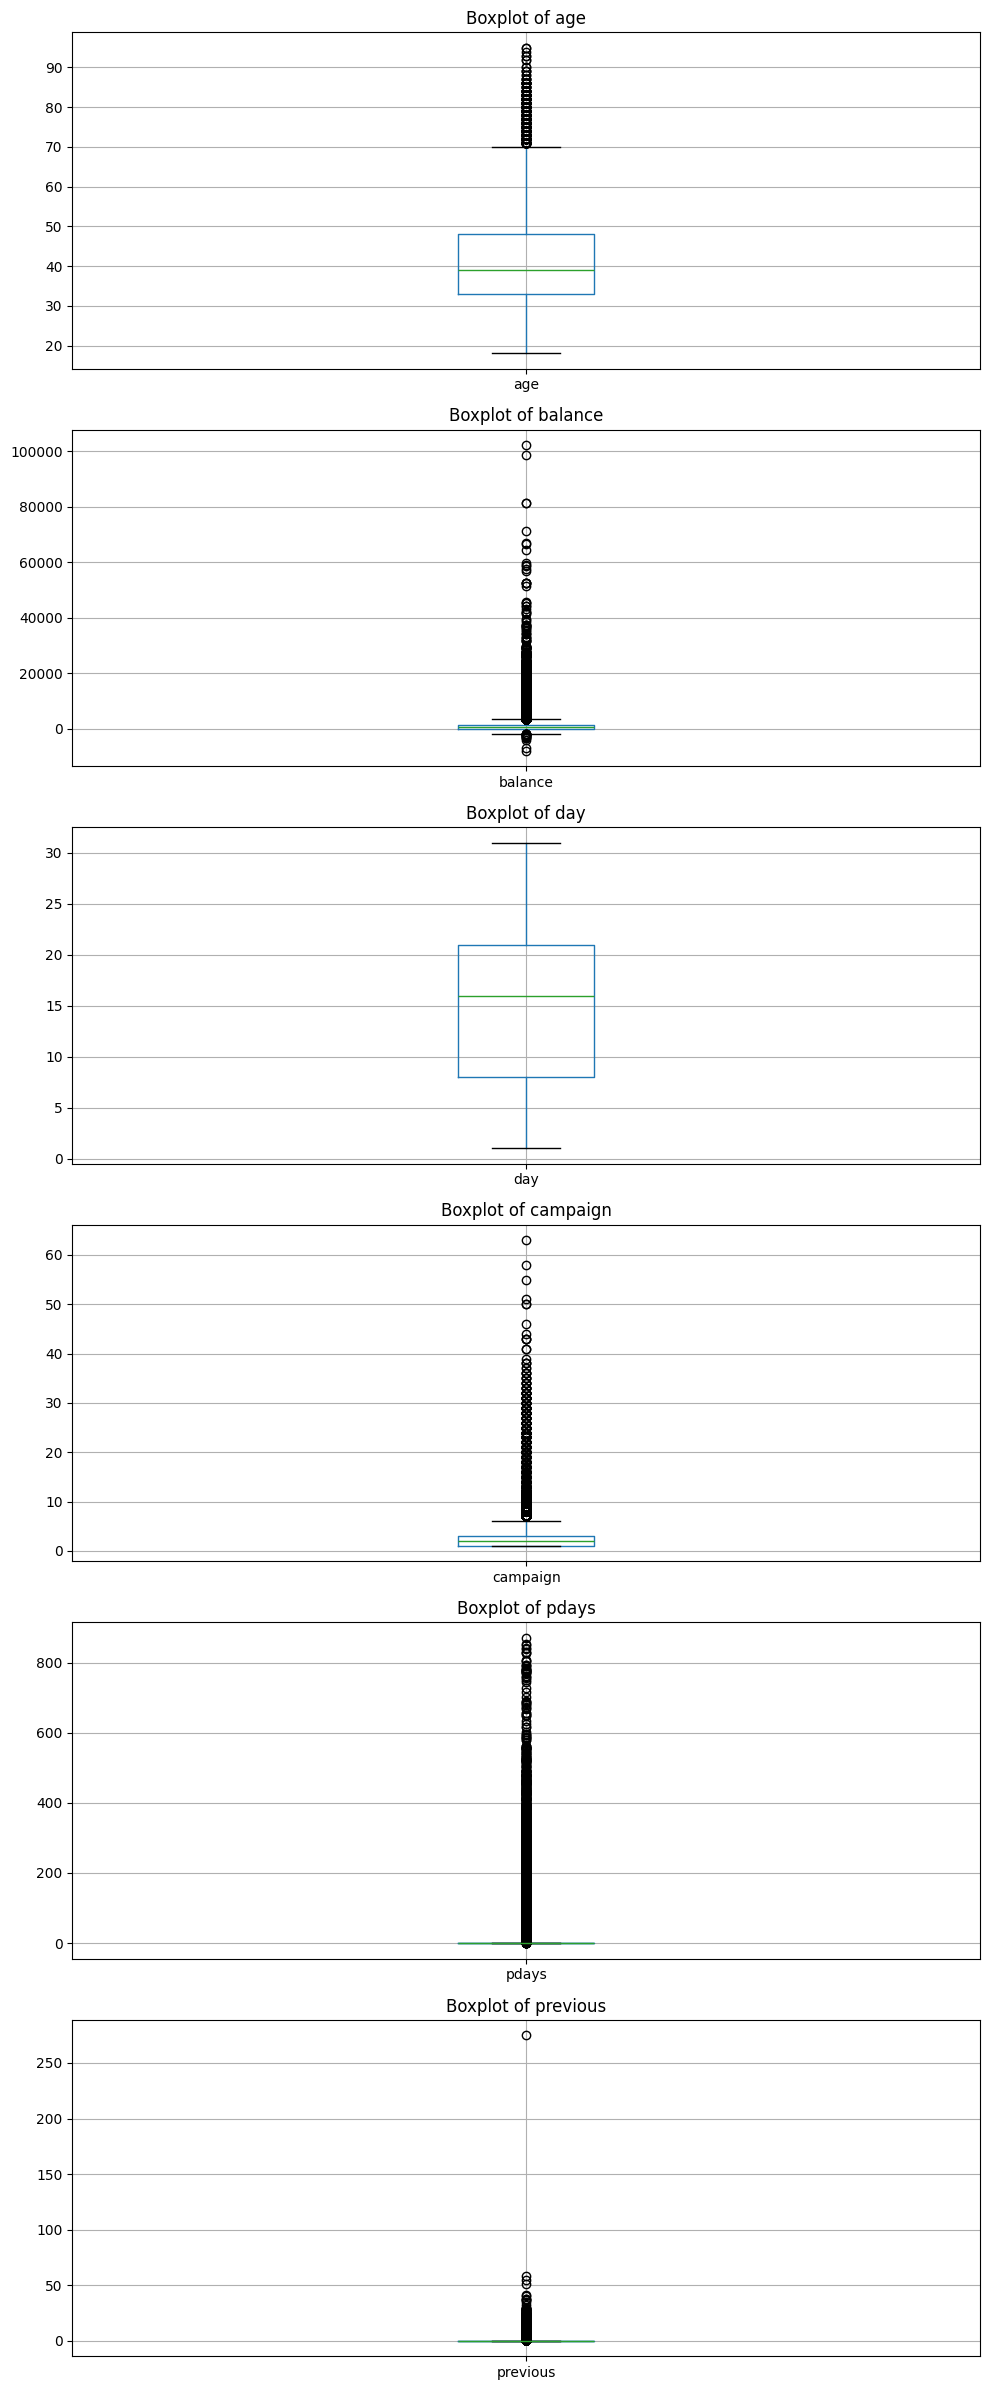

Combined boxplot saved.


In [60]:
# -----------------------------------------------------------------------------
# Numerical feature distributions: histograms and boxplots
# -----------------------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove target if numeric? y is object, so fine. Remove row_index and duration.
numeric_cols = [c for c in numeric_cols if c not in ["row_index"] + EXCLUDE_FEATURES]
print("\nNumerical columns:", numeric_cols)

# Histograms
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], f"hist_{col}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Histogram saved for {col}")

# Boxplots for all numeric features
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 4*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], "boxplots_all_numeric.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Combined boxplot saved.")

### 6.6 Categorical Feature Frequency Plots



Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


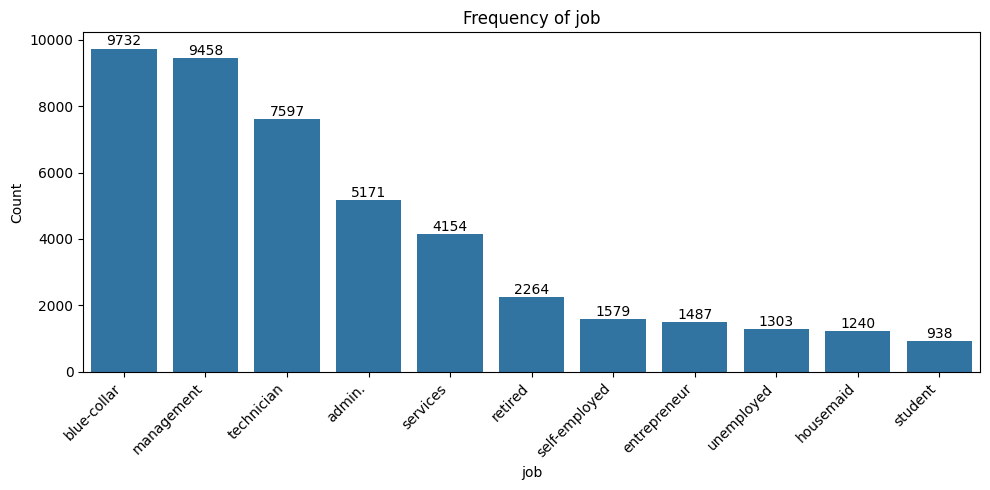

Frequency plot saved for job


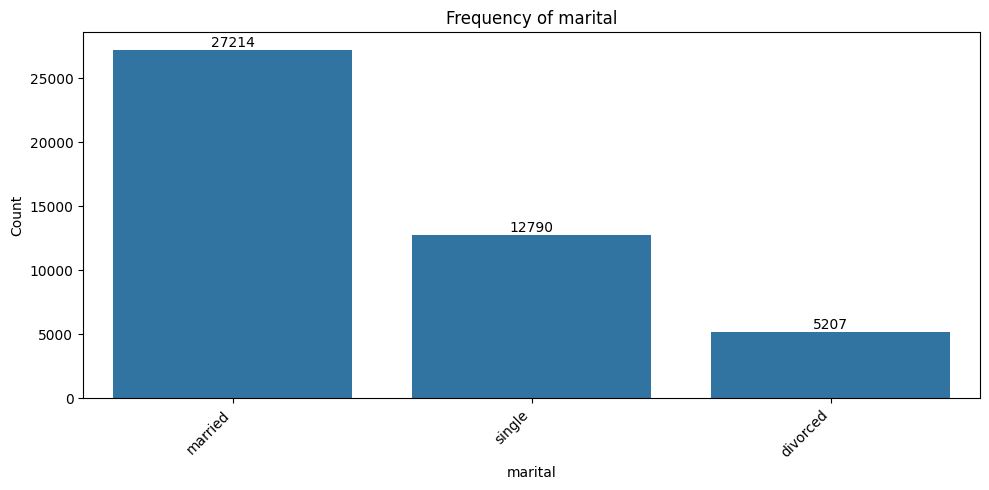

Frequency plot saved for marital


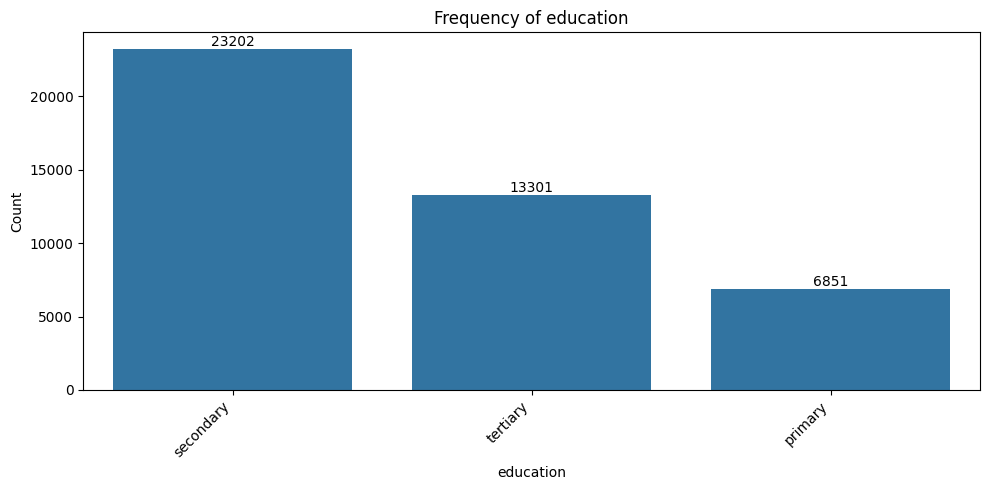

Frequency plot saved for education


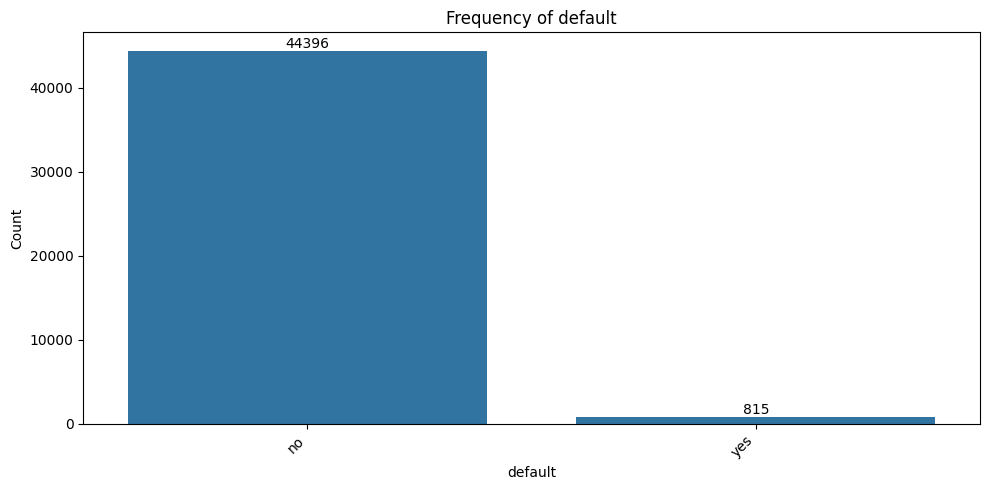

Frequency plot saved for default


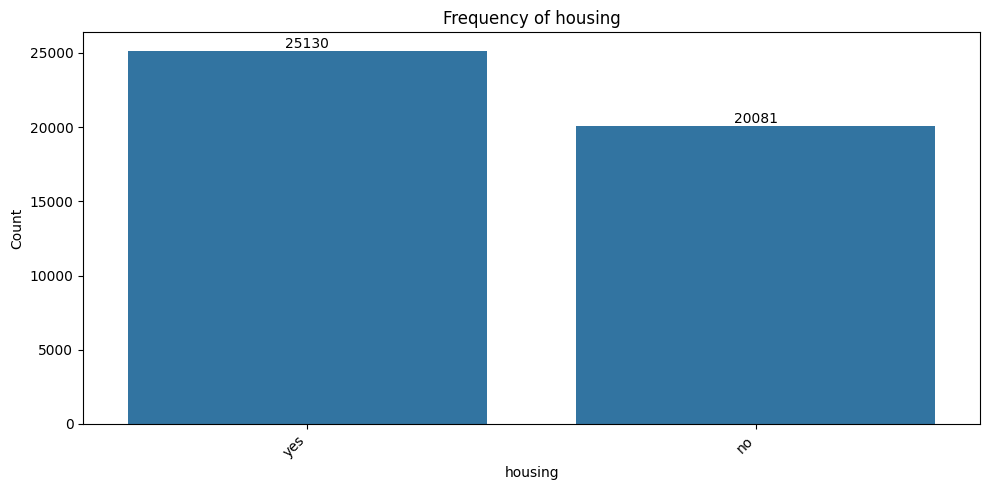

Frequency plot saved for housing


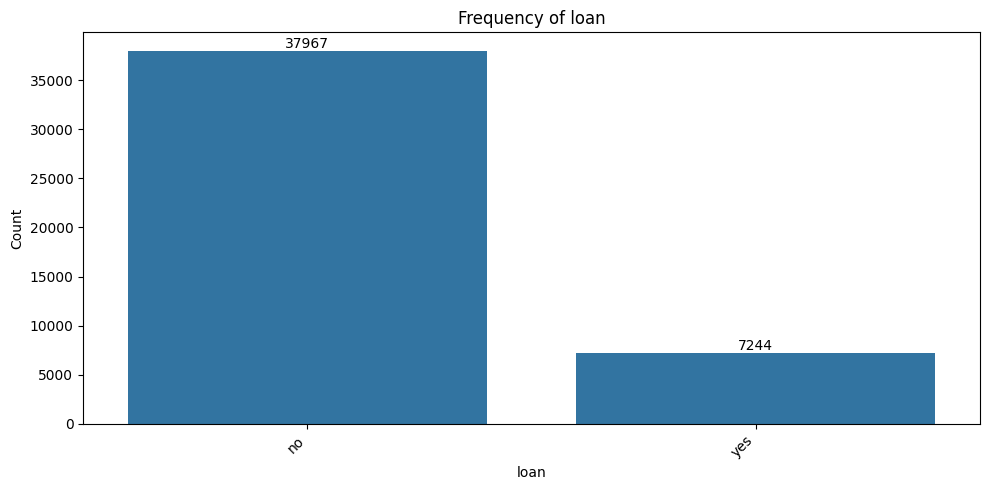

Frequency plot saved for loan


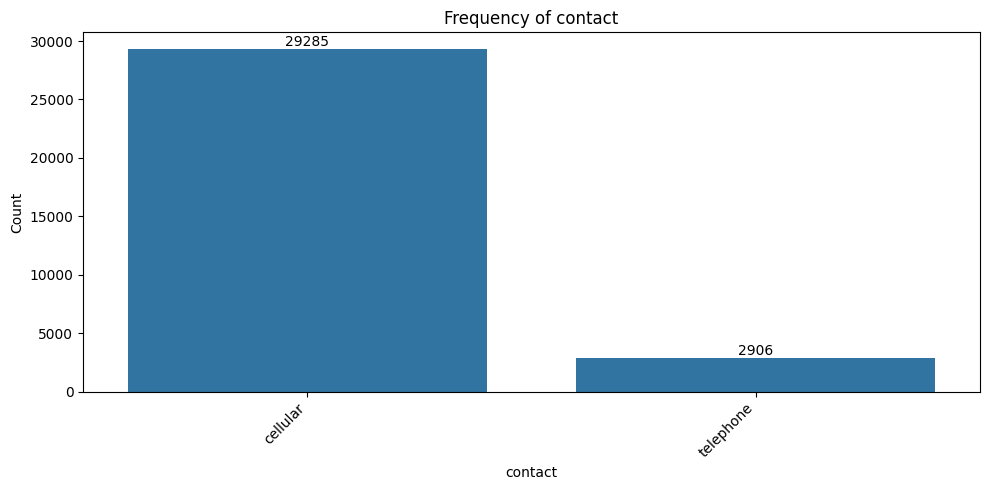

Frequency plot saved for contact


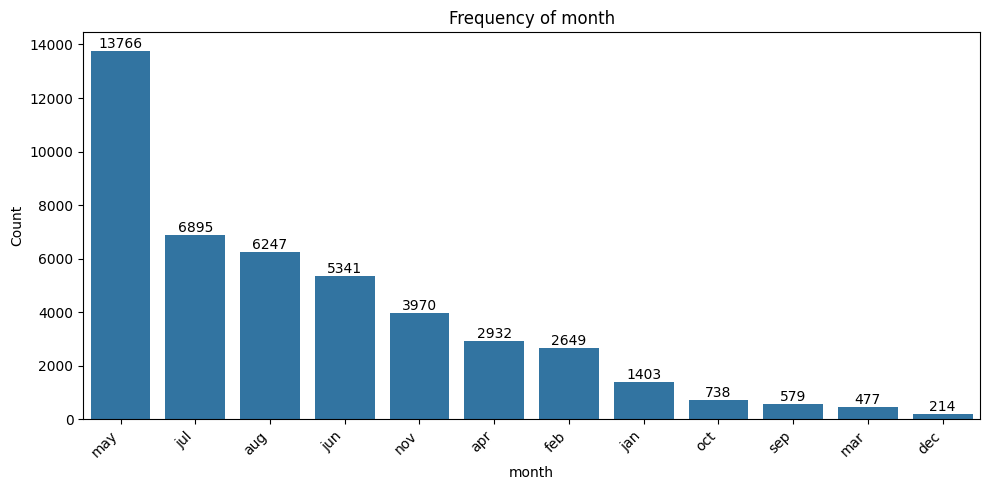

Frequency plot saved for month


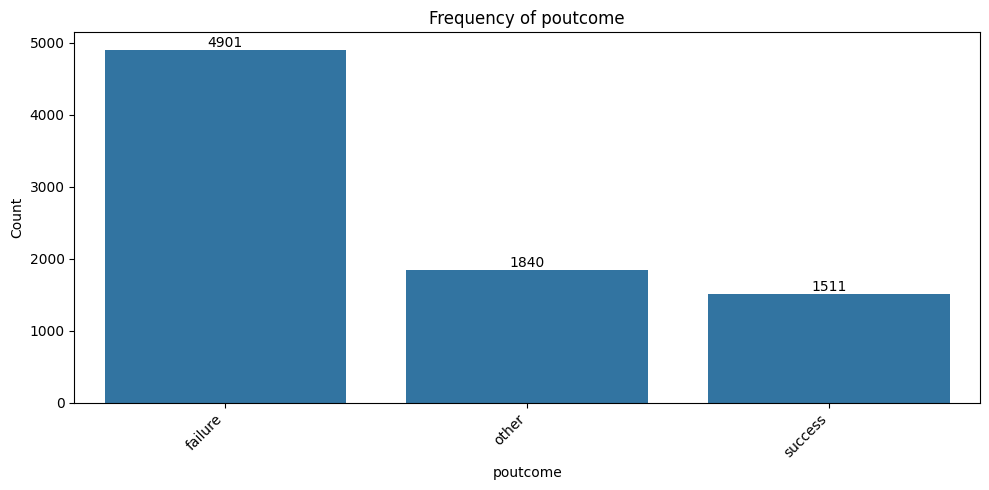

Frequency plot saved for poutcome


In [61]:
# -----------------------------------------------------------------------------
# Categorical feature frequency plots (bar charts)
# -----------------------------------------------------------------------------
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ["y"]]  # target handled separately
print("\nCategorical columns:", categorical_cols)

for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"Frequency of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    # Add value labels on bars
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha='center', va='bottom')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], f"cat_{col}_freq.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Frequency plot saved for {col}")

### 6.7 Numeric Feature by Target Boxplots


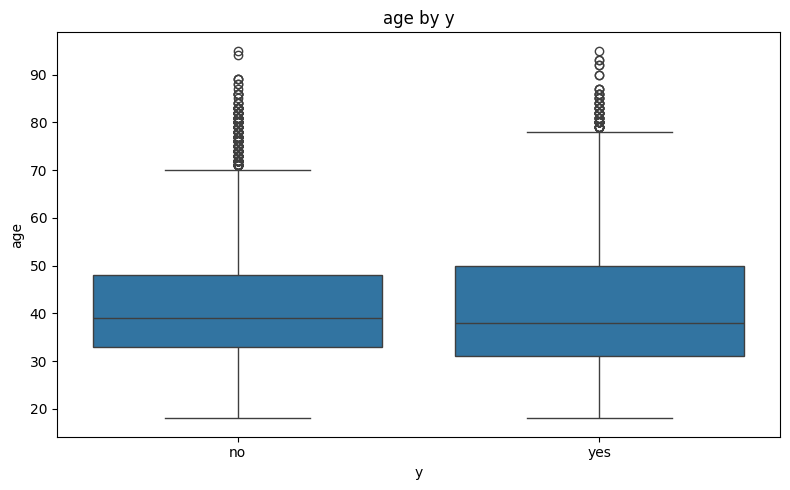

Boxplot saved for age vs target


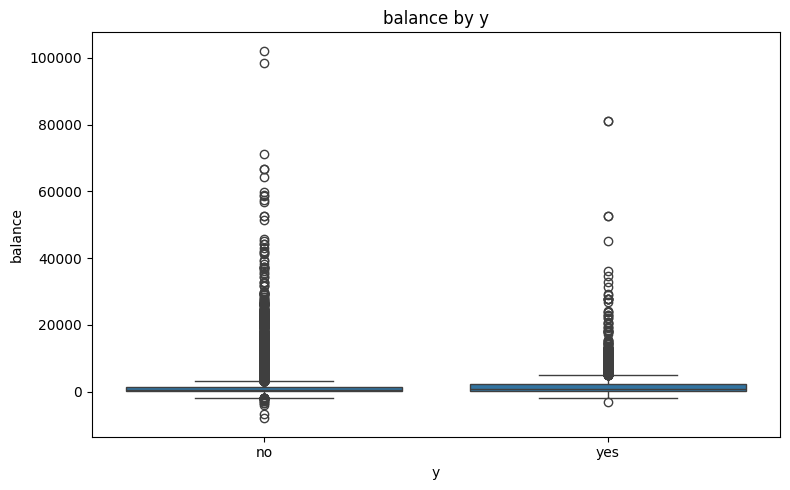

Boxplot saved for balance vs target


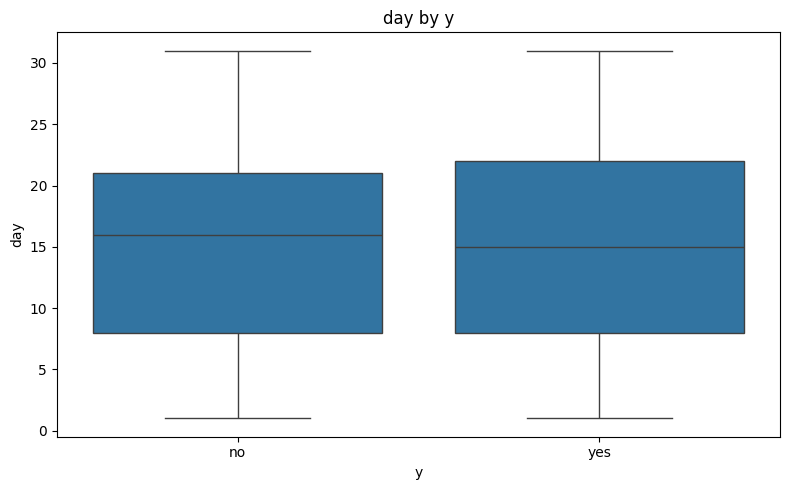

Boxplot saved for day vs target


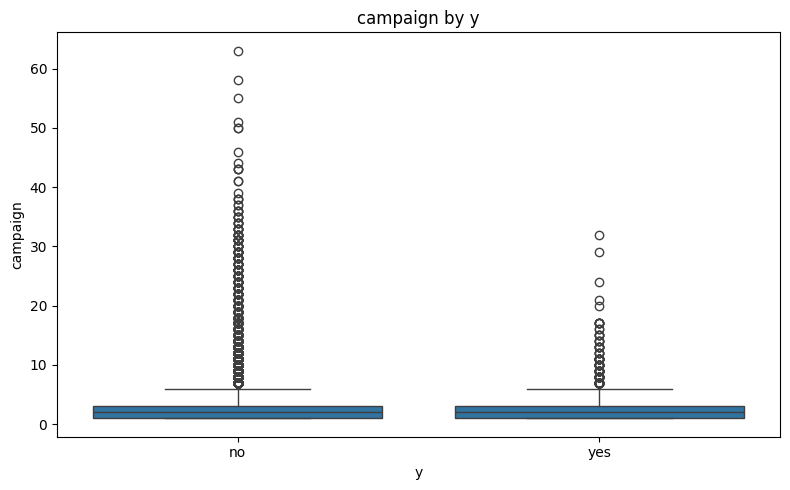

Boxplot saved for campaign vs target


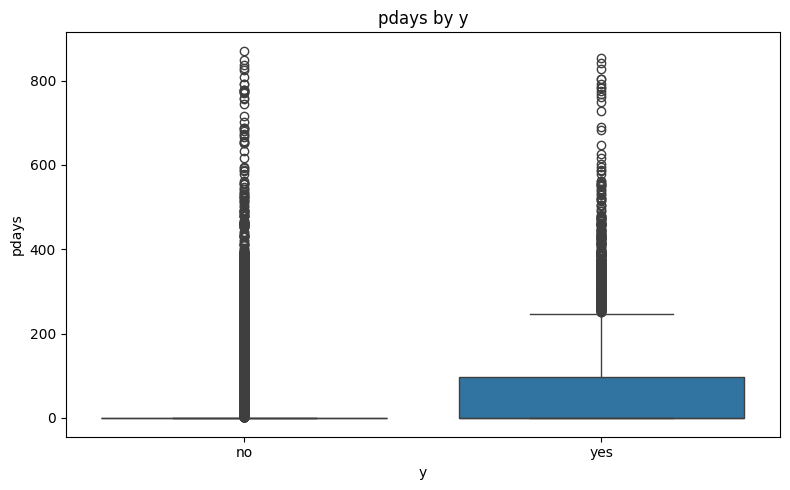

Boxplot saved for pdays vs target


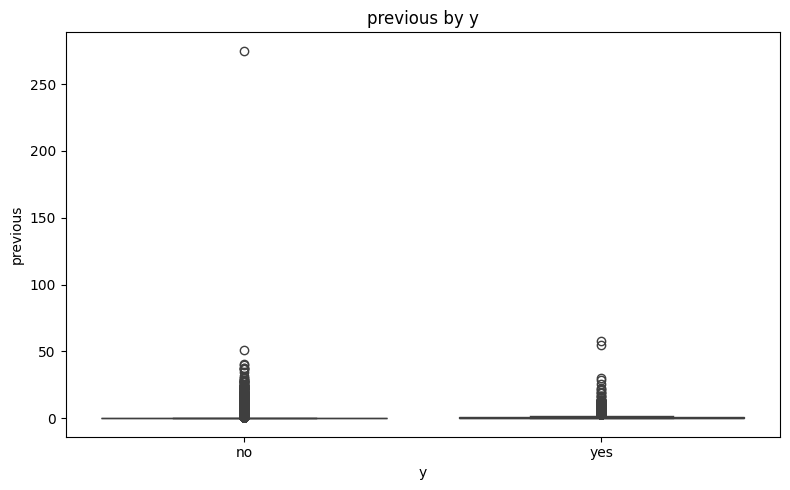

Boxplot saved for previous vs target


In [62]:
# -----------------------------------------------------------------------------
# Numeric feature vs target (boxplots)
# -----------------------------------------------------------------------------
target = "y"
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 5))
    # Ensure order of categories (yes/no)
    order = df[target].unique()
    sns.boxplot(x=target, y=col, data=df, order=order, ax=ax)
    ax.set_title(f"{col} by {target}")
    ax.set_xlabel(target)
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], f"box_{col}_by_target.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Boxplot saved for {col} vs target")

### 6.8 Missingness/Unknown Pattern Heatmap


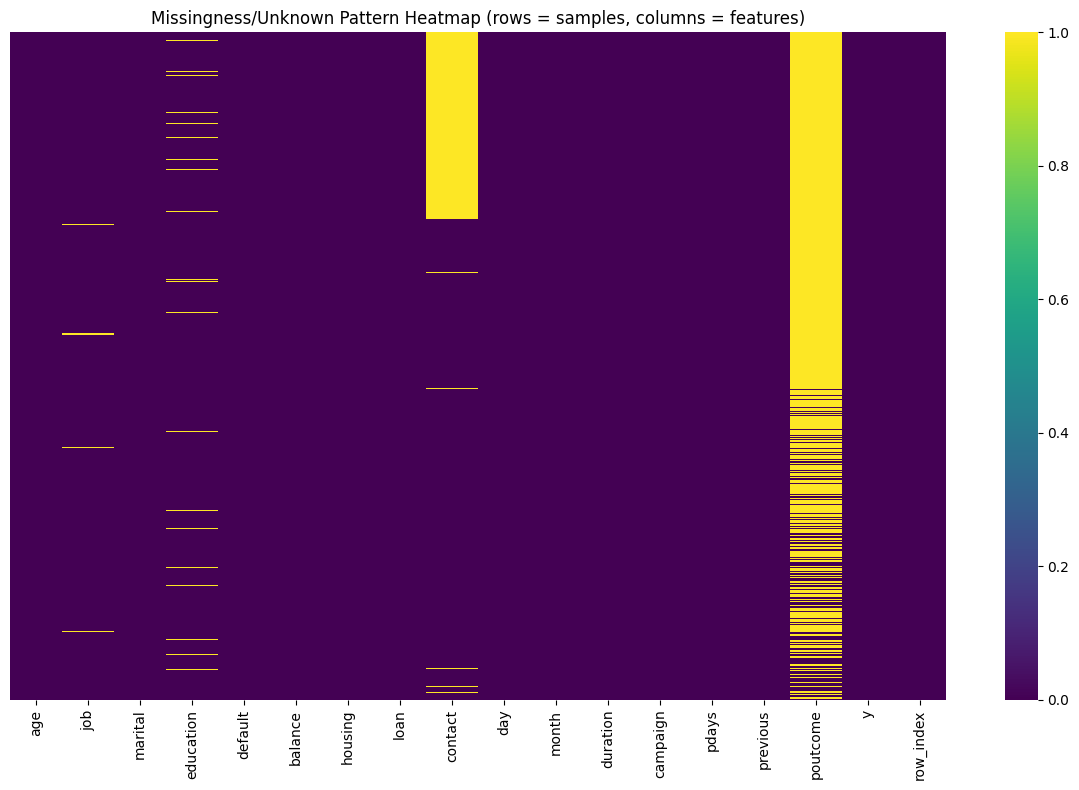

Missingness heatmap saved.


In [63]:
# -----------------------------------------------------------------------------
# Heatmap of missingness (including unknown placeholders)
# -----------------------------------------------------------------------------
# Create a binary matrix indicating where values are NaN or "unknown"
missing_matrix = df.copy()
for col in missing_matrix.select_dtypes(include=["object", "category"]).columns:
    # Mark unknown strings as missing
    unknown_mask = missing_matrix[col].astype(str).str.lower().isin([v.lower() for v in unknown_vals])
    missing_matrix.loc[unknown_mask, col] = np.nan

# Now create a binary matrix of missingness (1 if missing)
missing_binary = missing_matrix.isna().astype(int)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(missing_binary, cbar=True, cmap='viridis', yticklabels=False)
plt.title("Missingness/Unknown Pattern Heatmap (rows = samples, columns = features)")
plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], "missingness_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Missingness heatmap saved.")

### 6.9 Correlation Heatmap of Numeric Features


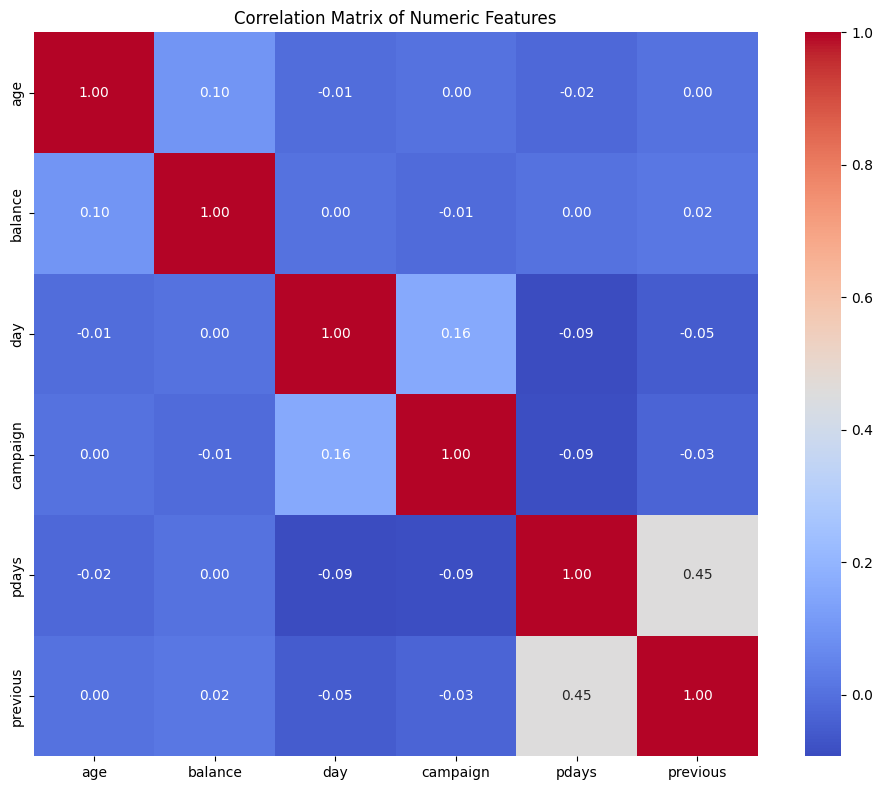

Correlation heatmap saved.


In [64]:
# -----------------------------------------------------------------------------
# Correlation heatmap of numeric features
# -----------------------------------------------------------------------------
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title("Correlation Matrix of Numeric Features")
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], "correlation_heatmap.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Correlation heatmap saved.")
else:
    print("Only one numeric feature, no correlation heatmap generated.")

### 6.10 Campaign-Specific: Subscription Rate by Month and Contact Type


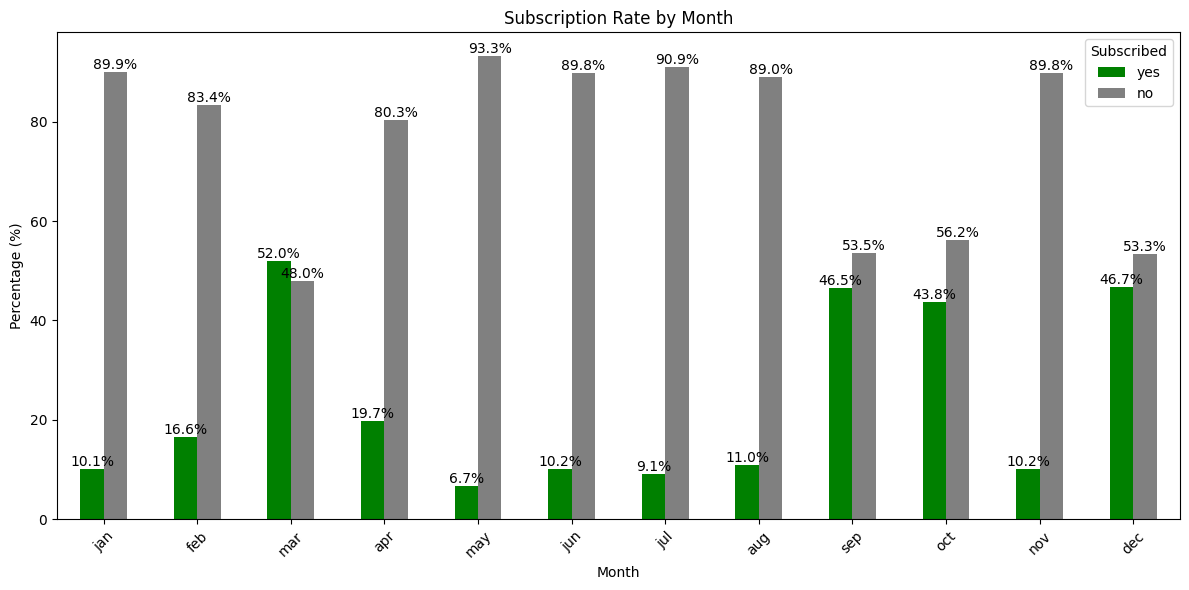

Subscription rate by month saved.


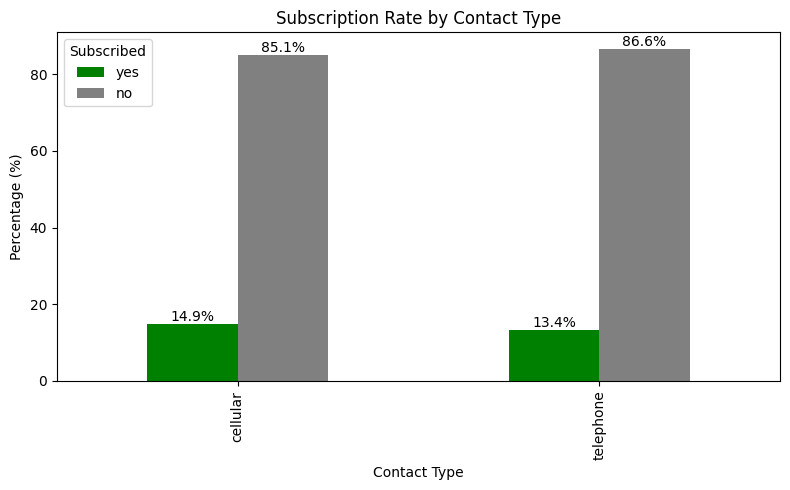

Subscription rate by contact type saved.


In [65]:
# -----------------------------------------------------------------------------
# Subscription rate by month and contact type
# -----------------------------------------------------------------------------
# Month
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_counts = df.groupby('month')[target].value_counts(normalize=True).unstack(fill_value=0) * 100
# Reindex to have all months in order
month_counts = month_counts.reindex(month_order, fill_value=0)
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
month_counts[['yes', 'no']].plot(kind='bar', ax=ax, stacked=False, color=['green', 'gray'])
ax.set_title('Subscription Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Subscribed')
# Annotate percentages on bars
for p in ax.patches:
    height = p.get_height()
    if height > 1:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], "sub_rate_by_month.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Subscription rate by month saved.")

# Contact type
if 'contact' in df.columns:
    contact_counts = df.groupby('contact')[target].value_counts(normalize=True).unstack(fill_value=0) * 100
    fig, ax = plt.subplots(figsize=(8, 5))
    contact_counts[['yes', 'no']].plot(kind='bar', ax=ax, stacked=False, color=['green', 'gray'])
    ax.set_title('Subscription Rate by Contact Type')
    ax.set_xlabel('Contact Type')
    ax.set_ylabel('Percentage (%)')
    ax.legend(title='Subscribed')
    for p in ax.patches:
        height = p.get_height()
        if height > 1:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width()/2., height),
                        ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], "sub_rate_by_contact.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Subscription rate by contact type saved.")

## 7. Preprocessing and Data Preparation


### 7.1 Handling "unknown" Categories


In [66]:
# -----------------------------------------------------------------------------
# Decide how to handle "unknown" values per column
# -----------------------------------------------------------------------------
print("\n=== Handling 'unknown' categories ===")
# We will treat 'unknown' as a separate category (i.e., keep as its own level)
# for categorical columns. For numeric columns, 'unknown' is not present.
# This is because 'unknown' may be informative (e.g., job unknown could be a distinct group).
# We will not impute with mode; we'll keep it as its own category.
# For columns with many unknowns, we might consider treating as missing, but here we'll keep.

# We'll define a mapping of columns to handling strategy (for documentation)
unknown_handling = {}
for col in df.select_dtypes(include=["object", "category"]).columns:
    if col == target:
        continue
    if col in unknown_summary:
        unknown_handling[col] = "keep as separate category"
    else:
        unknown_handling[col] = "no unknown values"
print("Unknown handling strategy:")
for col, strategy in unknown_handling.items():
    print(f"  {col}: {strategy}")

# Save to artifact
with open(os.path.join(dirs["artifacts"], "unknown_handling.json"), "w") as f:
    json.dump(unknown_handling, f, indent=2)


=== Handling 'unknown' categories ===
Unknown handling strategy:
  job: no unknown values
  marital: no unknown values
  education: no unknown values
  default: no unknown values
  housing: no unknown values
  loan: no unknown values
  contact: no unknown values
  month: no unknown values
  poutcome: no unknown values


### 7.2 Define Final Feature Lists


In [67]:
# -----------------------------------------------------------------------------
# Define final lists for NUMERIC, CATEGORICAL, ORDINAL columns
# -----------------------------------------------------------------------------
# Exclude target, row_index, and duration
exclude_cols = ["y", "row_index"] + EXCLUDE_FEATURES

# Numeric columns (excluding excluded)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Categorical columns (object or category)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in exclude_cols and c != target]

# Ordinal columns (none identified in this dataset; we'll keep empty)
ordinal_cols = []

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Ordinal columns:", ordinal_cols)

# Save feature metadata
feature_metadata = {
    "numeric": numeric_cols,
    "categorical": categorical_cols,
    "ordinal": ordinal_cols,
    "excluded": exclude_cols,
    "target": target
}
with open(os.path.join(dirs["artifacts"], "feature_metadata.json"), "w") as f:
    json.dump(feature_metadata, f, indent=2)
print("Feature metadata saved to artifacts/feature_metadata.json")

Numeric columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Ordinal columns: []
Feature metadata saved to artifacts/feature_metadata.json


### 7.3 Stratified Train/Test Split


In [68]:
# -----------------------------------------------------------------------------
# Create stratified, leakage-safe 80/20 train/test split
# -----------------------------------------------------------------------------
print("\n=== Train/Test Split ===")
# Use only features (X) and target (y)
X = df.drop(columns=[target] + exclude_cols, axis=1)
y = df[target]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set size:     {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("Class distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)

# Verify no row overlap (indices should be disjoint)
train_indices = X_train.index
test_indices = X_test.index
overlap = set(train_indices) & set(test_indices)
if overlap:
    print(f"WARNING: {len(overlap)} overlapping rows found!")
else:
    print("No row overlap: split is clean.")

# Save split manifest
split_manifest = {
    "train_size": len(X_train),
    "test_size": len(X_test),
    "train_indices": train_indices.tolist(),
    "test_indices": test_indices.tolist(),
    "random_state": 42,
    "stratify": True,
    "target": target
}
with open(os.path.join(dirs["artifacts"], "split_manifest.json"), "w") as f:
    json.dump(split_manifest, f, indent=2)
print("Split manifest saved to artifacts/split_manifest.json")


=== Train/Test Split ===


Training set size: 36168 (80.0%)
Test set size:     9043 (20.0%)
Class distribution in training set:
y
no     88.301814
yes    11.698186
Name: proportion, dtype: float64
Class distribution in test set:
y
no     88.300343
yes    11.699657
Name: proportion, dtype: float64
No row overlap: split is clean.
Split manifest saved to artifacts/split_manifest.json


### 7.4 Build Preprocessing Pipelines


In [69]:
# -----------------------------------------------------------------------------
# Build four model-specific ColumnTransformer + Pipeline objects
# -----------------------------------------------------------------------------
print("\n=== Building Preprocessing Pipelines ===")

# Define transformers for each pipeline

# ---------- Pipeline for GaussianNB ----------
# Numeric features only: median impute + StandardScaler
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer for GaussianNB
preprocessor_gaussian = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols)
    ],
    remainder='drop'  # ignore categorical features
)

# GaussianNB pipeline
pipeline_gaussian = Pipeline([
    ('preprocessor', preprocessor_gaussian),
    ('classifier', GaussianNB())
])

print("GaussianNB pipeline built.")

# ---------- Pipeline for BernoulliNB ----------
# Numeric: discretize into bins and one-hot encode
discretizer = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='quantile')
# Categorical: one-hot encode (handle_unknown='ignore')
categorical_transformer_bern = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor_bernoulli = ColumnTransformer(
    transformers=[
        ('num_discrete', discretizer, numeric_cols),
        ('cat', categorical_transformer_bern, categorical_cols)
    ],
    remainder='drop'
)

pipeline_bernoulli = Pipeline([
    ('preprocessor', preprocessor_bernoulli),
    ('classifier', BernoulliNB())
])

print("BernoulliNB pipeline built.")

# ---------- Custom SafeOrdinalToNonNegative Transformer ----------
class SafeOrdinalToNonNegative(BaseEstimator, TransformerMixin):
    """
    Safely encode categorical columns to non-negative integers.
    Missing values are handled by filling with a dedicated 'unknown' code.
    """
    def __init__(self, unknown_code=-1):
        self.unknown_code = unknown_code
        self.encoders = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            # Get all unique values, including NaN
            uniq = X[col].unique()
            # Create a mapping from value to integer, starting from 0
            # Put 'unknown' code as a fallback for unseen values
            # We'll assign the code -1 for missing, but we need to shift to non-negative.
            # We'll reserve 0 for unknowns, so we'll map unknowns to 0 and others to 1...n
            # But to keep it simple, we'll use OrdinalEncoder with a custom mapping.
            # We'll fit a simple dict: value -> integer, with unknown as 0.
            # We'll collect all values and assign 1..n, and map missing to 0.
            # However, we want to preserve the category order as seen in fit.
            # We'll use a list of unique values (excluding NaN) and assign 1..n.
            # Then unknown (NaN or unseen) will be 0.
            # We'll store the mapping.
            # First, drop NaN for fitting
            clean_vals = X[col].dropna().unique()
            # Sort for consistency
            clean_vals = sorted(clean_vals)
            mapping = {val: i+1 for i, val in enumerate(clean_vals)}  # 1-indexed
            self.encoders[col] = mapping
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        X_trans = X.copy()
        for col in X.columns:
            mapping = self.encoders[col]
            # Apply mapping, default to 0 for unknown or NaN
            X_trans[col] = X[col].map(mapping).fillna(0).astype(int)
        return X_trans.values

# ---------- Pipeline for CategoricalNB ----------
# Numeric: discretize to ordinal bins (KBinsDiscretizer with encode='ordinal')
discretizer_ordinal = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
# Categorical: use SafeOrdinalToNonNegative
safe_ordinal = SafeOrdinalToNonNegative(unknown_code=0)

preprocessor_categorical = ColumnTransformer(
    transformers=[
        ('num_ordinal', discretizer_ordinal, numeric_cols),
        ('cat_ordinal', safe_ordinal, categorical_cols)
    ],
    remainder='drop'
)

pipeline_categorical = Pipeline([
    ('preprocessor', preprocessor_categorical),
    ('classifier', CategoricalNB())
])

print("CategoricalNB pipeline built.")

# ---------- Pipeline for DummyClassifier (most-frequent) ----------
# Reuse Bernoulli preprocessor (one-hot) for dummy
pipeline_dummy = Pipeline([
    ('preprocessor', preprocessor_bernoulli),  # same as Bernoulli
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

print("DummyClassifier pipeline built.")

# Save pipelines (as joblib) for later use
joblib.dump(pipeline_gaussian, os.path.join(dirs["models"], "pipeline_gaussian.joblib"))
joblib.dump(pipeline_bernoulli, os.path.join(dirs["models"], "pipeline_bernoulli.joblib"))
joblib.dump(pipeline_categorical, os.path.join(dirs["models"], "pipeline_categorical.joblib"))
joblib.dump(pipeline_dummy, os.path.join(dirs["models"], "pipeline_dummy.joblib"))
print("All four pipelines saved to models/ directory.")


=== Building Preprocessing Pipelines ===
GaussianNB pipeline built.
BernoulliNB pipeline built.
CategoricalNB pipeline built.
DummyClassifier pipeline built.
All four pipelines saved to models/ directory.


### 7.5 Verify Pipelines on Small Sample


In [70]:
# -----------------------------------------------------------------------------
# Verify each pipeline fits and predicts on a small sample
# -----------------------------------------------------------------------------
print("\n=== Pipeline Verification on Sample ===")

sample_size = 50
X_sample = X_train.sample(n=sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

for name, pipe in [
    ("GaussianNB", pipeline_gaussian),
    ("BernoulliNB", pipeline_bernoulli),
    ("CategoricalNB", pipeline_categorical),
    ("Dummy", pipeline_dummy)
]:
    try:
        pipe.fit(X_sample, y_sample)
        preds = pipe.predict(X_sample)
        print(f"{name:15} fit and predict OK. Pred shape: {preds.shape}")
    except Exception as e:
        print(f"{name:15} FAILED: {e}")

# Additional check: CategoricalNB preprocessor output should have min >= 0
try:
    X_trans_cat = pipeline_categorical.named_steps['preprocessor'].transform(X_sample)
    min_val = X_trans_cat.min()
    print(f"CategoricalNB preprocessor transformed min value: {min_val} (should be >= 0)")
    if min_val < 0:
        print("WARNING: negative values detected!")
except Exception as e:
    print(f"Could not check CategoricalNB preprocessor: {e}")


=== Pipeline Verification on Sample ===
GaussianNB      fit and predict OK. Pred shape: (50,)
BernoulliNB     fit and predict OK. Pred shape: (50,)
CategoricalNB   fit and predict OK. Pred shape: (50,)
Dummy           fit and predict OK. Pred shape: (50,)
CategoricalNB preprocessor transformed min value: 0.0 (should be >= 0)


### 7.6 Save Preprocessed Data and Final Artifacts


In [71]:
# -----------------------------------------------------------------------------
# Save preprocessed data splits and final artifacts
# -----------------------------------------------------------------------------
print("\n=== Saving Preprocessed Data ===")

# Save X_train, X_test, y_train, y_test as CSV (processed)
X_train.to_csv(os.path.join(dirs["data_processed"], "X_train.csv"), index=False)
X_test.to_csv(os.path.join(dirs["data_processed"], "X_test.csv"), index=False)
y_train.to_csv(os.path.join(dirs["data_processed"], "y_train.csv"), index=False)
y_test.to_csv(os.path.join(dirs["data_processed"], "y_test.csv"), index=False)

print("Training/test splits saved to data/processed/")

# Save feature metadata again (already saved)
# Save the list of columns used in each preprocessor for reference
preprocessor_columns = {
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
}
with open(os.path.join(dirs["artifacts"], "preprocessor_columns.json"), "w") as f:
    json.dump(preprocessor_columns, f, indent=2)

print("All preprocessing artifacts saved.")


=== Saving Preprocessed Data ===
Training/test splits saved to data/processed/
All preprocessing artifacts saved.


## 8. Universal cross_validate_model function


In [72]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import time

def cross_validate_model(pipeline, X, y, n_splits=5, random_state=42):
    """
    Perform stratified 5-fold cross-validation and return metrics.
    
    Parameters:
    -----------
    pipeline : sklearn Pipeline
        The full pipeline (preprocessing + classifier)
    X : pd.DataFrame or np.ndarray
        Feature matrix
    y : pd.Series or np.ndarray
        Target labels
    n_splits : int
        Number of folds for StratifiedKFold
    random_state : int
        Random state for reproducibility
    
    Returns:
    --------
    dict with keys:
        'mean_accuracy', 'std_accuracy'
        'mean_macro_f1', 'std_macro_f1'
        'mean_weighted_f1', 'std_weighted_f1'
        'fold_macro_f1' : list of macro F1 scores per fold
        'cv_time' : wall-clock time in seconds for the cross-validation
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring = ['accuracy', 'f1_macro', 'f1_weighted']
    
    start_time = time.time()
    cv_results = cross_validate(
        pipeline, X, y, cv=cv, scoring=scoring,
        return_train_score=False, n_jobs=-1
    )
    elapsed = time.time() - start_time
    
    results = {
        'mean_accuracy': cv_results['test_accuracy'].mean(),
        'std_accuracy': cv_results['test_accuracy'].std(),
        'mean_macro_f1': cv_results['test_f1_macro'].mean(),
        'std_macro_f1': cv_results['test_f1_macro'].std(),
        'mean_weighted_f1': cv_results['test_f1_weighted'].mean(),
        'std_weighted_f1': cv_results['test_f1_weighted'].std(),
        'fold_macro_f1': cv_results['test_f1_macro'].tolist(),
        'cv_time': elapsed
    }
    return results

## 9. Cross-validate all four pipelines on identical folds


In [73]:
core_pipelines = {
    'Dummy': pipeline_dummy,
    'GaussianNB': pipeline_gaussian,
    'BernoulliNB': pipeline_bernoulli,
    'CategoricalNB': pipeline_categorical
}

cv_results_all = {}
for name, pipe in core_pipelines.items():
    print(f"Cross-validating {name}...")
    cv_results_all[name] = cross_validate_model(pipe, X_train, y_train, n_splits=5)
    print(f"  Mean macro F1: {cv_results_all[name]['mean_macro_f1']:.4f} (+/- {cv_results_all[name]['std_macro_f1']:.4f})")
    print(f"  Mean accuracy: {cv_results_all[name]['mean_accuracy']:.4f}")
    print(f"  Mean weighted F1: {cv_results_all[name]['mean_weighted_f1']:.4f}")
    print(f"  CV time: {cv_results_all[name]['cv_time']:.2f}s\n")

# Build a results DataFrame
results_df = pd.DataFrame([
    {
        'model': name,
        'accuracy_mean': res['mean_accuracy'],
        'accuracy_std': res['std_accuracy'],
        'macro_f1_mean': res['mean_macro_f1'],
        'macro_f1_std': res['std_macro_f1'],
        'weighted_f1_mean': res['mean_weighted_f1'],
        'weighted_f1_std': res['std_weighted_f1'],
        'cv_time': res['cv_time'],
        'fold_macro_f1': res['fold_macro_f1']
    }
    for name, res in cv_results_all.items()
])

# Sort by mean macro F1 descending
results_df = results_df.sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)

# Save to CSV
results_df.to_csv(os.path.join(dirs["results"], "cv_results.csv"), index=False)
print("Cross-validation results saved to results/cv_results.csv")
print("\nFull CV results DataFrame:")
print(results_df[['model', 'accuracy_mean', 'macro_f1_mean', 'weighted_f1_mean', 'macro_f1_std']])

Cross-validating Dummy...
  Mean macro F1: 0.4689 (+/- 0.0000)
  Mean accuracy: 0.8830
  Mean weighted F1: 0.8282
  CV time: 37.93s

Cross-validating GaussianNB...
  Mean macro F1: 0.5389 (+/- 0.0070)
  Mean accuracy: 0.8379
  Mean weighted F1: 0.8233
  CV time: 7.91s

Cross-validating BernoulliNB...
  Mean macro F1: 0.6497 (+/- 0.0022)
  Mean accuracy: 0.8385
  Mean weighted F1: 0.8467
  CV time: 2.14s

Cross-validating CategoricalNB...
  Mean macro F1: 0.6629 (+/- 0.0042)
  Mean accuracy: 0.8748
  Mean weighted F1: 0.8676
  CV time: 1.74s

Cross-validation results saved to results/cv_results.csv

Full CV results DataFrame:
           model  accuracy_mean  macro_f1_mean  weighted_f1_mean  macro_f1_std
0  CategoricalNB       0.874834       0.662869          0.867643      0.004153
1    BernoulliNB       0.838504       0.649668          0.846694      0.002217
2     GaussianNB       0.837923       0.538937          0.823346      0.006985
3          Dummy       0.883018       0.468938     

## 10. Model selection based on training-only CV evidence


In [74]:
print("\n=== Model Selection ===")
# Select model with highest mean macro F1
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_macro_f1 = best_row['macro_f1_mean']
best_std = best_row['macro_f1_std']

# Second-best
second_row = results_df.iloc[1]
second_best_model = second_row['model']
second_macro_f1 = second_row['macro_f1_mean']

gap = float(best_macro_f1 - second_macro_f1)

print(f"Best model: {best_model_name}")
print(f"  Mean macro F1: {best_macro_f1:.4f} +/- {best_std:.4f}")
print(f"Second best: {second_best_model}")
print(f"  Mean macro F1: {second_macro_f1:.4f}")
print(f"Gap: {gap:.4f}")

# Compare gap to best model's standard deviation
if gap > best_std:
    print("Decision: The difference IS larger than fold variability; we can claim superiority.")
else:
    print("Decision: The difference IS NOT larger than fold variability; the gap is within noise.")

# Print interpretation about accuracy vs macro F1
print("\n--- Accuracy vs Macro F1 ---")
for idx, row in results_df.iterrows():
    print(f"{row['model']:15} | Accuracy: {row['accuracy_mean']:.4f} | Macro F1: {row['macro_f1_mean']:.4f} | Weighted F1: {row['weighted_f1_mean']:.4f}")

print("\nNote: The Dummy baseline achieves relatively high accuracy (~{:.2f}%) because it always predicts the majority class, "
      "but its macro F1 is very low (~{:.2f}) – this demonstrates that accuracy is misleading for imbalanced data. "
      "We use macro F1 as our primary selection metric.".format(
          results_df[results_df['model']=='Dummy']['accuracy_mean'].values[0]*100,
          results_df[results_df['model']=='Dummy']['macro_f1_mean'].values[0]
      ))

# Save selection decision
selection_decision = {
    "selected_model": best_model_name,
    "criteria": "highest mean macro F1 from 5-fold CV",
    "mean_macro_f1": best_macro_f1,
    "std_macro_f1": best_std,
    "second_best_model": second_best_model,
    "second_best_macro_f1": second_macro_f1,
    "gap": gap,
    "gap_exceeds_std": float(gap > best_std),
    "rationale": f"Selected {best_model_name} because it achieved the highest macro F1; "
                  f"gap to second-best ({gap:.4f}) is {'greater' if gap > best_std else 'not greater'} than best model's fold variability ({best_std:.4f}).",
    "timestamp": datetime.datetime.now().isoformat()
}
with open(os.path.join(dirs["artifacts"], "model_selection.json"), "w") as f:
    json.dump(selection_decision, f, indent=2)
print("Model selection decision saved to artifacts/model_selection.json")


=== Model Selection ===
Best model: CategoricalNB
  Mean macro F1: 0.6629 +/- 0.0042
Second best: BernoulliNB
  Mean macro F1: 0.6497
Gap: 0.0132
Decision: The difference IS larger than fold variability; we can claim superiority.

--- Accuracy vs Macro F1 ---
CategoricalNB   | Accuracy: 0.8748 | Macro F1: 0.6629 | Weighted F1: 0.8676
BernoulliNB     | Accuracy: 0.8385 | Macro F1: 0.6497 | Weighted F1: 0.8467
GaussianNB      | Accuracy: 0.8379 | Macro F1: 0.5389 | Weighted F1: 0.8233
Dummy           | Accuracy: 0.8830 | Macro F1: 0.4689 | Weighted F1: 0.8282

Note: The Dummy baseline achieves relatively high accuracy (~88.30%) because it always predicts the majority class, but its macro F1 is very low (~0.47) – this demonstrates that accuracy is misleading for imbalanced data. We use macro F1 as our primary selection metric.
Model selection decision saved to artifacts/model_selection.json


## 11. Cross-Validation Comparison Bar/Error-Bar Chart


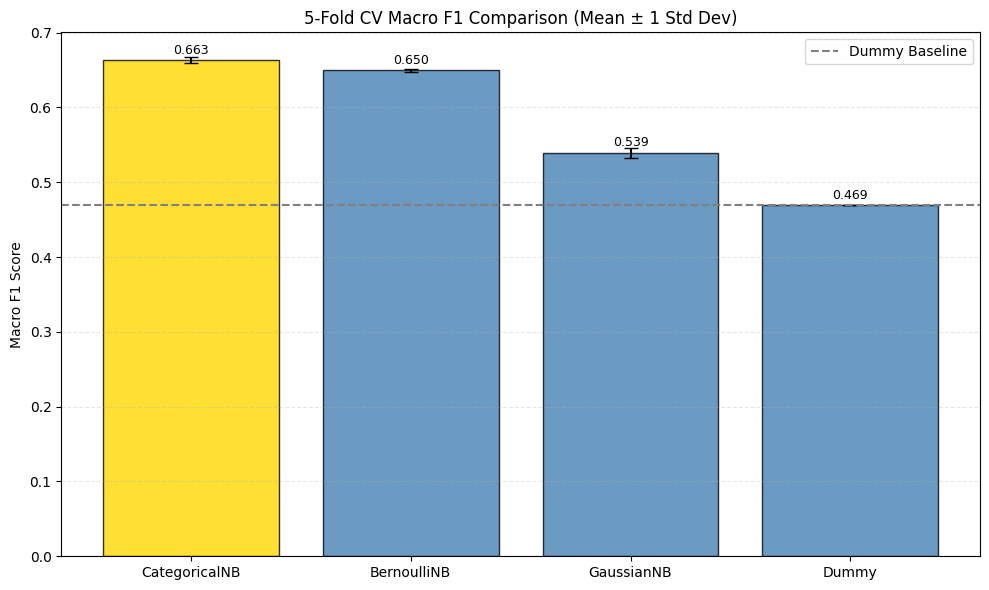

CV comparison chart saved to figures/cv_macro_f1_comparison.png


In [75]:
# -----------------------------------------------------------------------------
# 11. Bar chart of macro F1 mean ± std for all models
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Order models by macro F1 descending (already sorted)
models = results_df['model'].values
means = results_df['macro_f1_mean'].values
stds = results_df['macro_f1_std'].values

# Colors: highlight best in gold, others in steelblue
colors = ['gold' if m == best_model_name else 'steelblue' for m in models]

bars = ax.bar(models, means, yerr=stds, capsize=5, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold CV Macro F1 Comparison (Mean ± 1 Std Dev)')
ax.axhline(y=means[models.tolist().index('Dummy')], color='gray', linestyle='--', label='Dummy Baseline')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top of bars
for bar, mean_val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], "cv_macro_f1_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("CV comparison chart saved to figures/cv_macro_f1_comparison.png")

## 12. Feature-Group Ablation Using the Selected Model


In [76]:
print("\n=== Feature Group Ablation ===")
# Based on actual columns from Part 1:
demographic_cols = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
campaign_cols = ['contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']
# No economic context columns in this dataset; we'll skip that group.
# Combined is all features (excluding target, duration, row_index)
combined_cols = demographic_cols + campaign_cols

# Verify all columns exist in X_train
all_available = set(X_train.columns)
demo_avail = [c for c in demographic_cols if c in all_available]
camp_avail = [c for c in campaign_cols if c in all_available]
combined_avail = demo_avail + camp_avail

print(f"Demographic columns used: {demo_avail}")
print(f"Campaign/behavioral columns used: {camp_avail}")
print(f"Combined columns: {combined_avail}")

# Justification for grouping:
# - Demographic features capture client attributes (age, job, marital status, education, loan/default history)
#   These are static characteristics that influence propensity but carry ethical/fairness risks in banking.
# - Campaign features capture contact details (month, day, contact type, previous contacts, outcome)
#   These reflect the marketing strategy and are dynamic.
# - There are no macroeconomic indicators in this dataset (unlike some versions of the bank marketing data).

# Create a dictionary of groups
feature_groups = {
    'demographic_only': demo_avail,
    'campaign_only': camp_avail,
    'combined': combined_avail
}


=== Feature Group Ablation ===
Demographic columns used: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
Campaign/behavioral columns used: ['contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']
Combined columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


## 13. Run Feature-Group Ablation on Identical CV Folds


In [77]:
# -----------------------------------------------------------------------------
# 13. Run ablation: cross-validate selected model on each feature group
# -----------------------------------------------------------------------------
selected_pipeline = core_pipelines[best_model_name]
selected_classifier = selected_pipeline.named_steps['classifier']

# We'll reuse the same CV splits from the selected model's cross-validation
# To ensure identical splits, we'll generate them once.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(cv.split(X_train, y_train))

def run_feature_group_ablation(group_name, feature_list, X, y, classifier, cv_splits):
    """
    Run cross-validation on a subset of features, using the same classifier.
    Returns mean macro F1 and fold scores.
    """
    # Create a preprocessor for only these features
    # We need to replicate the same preprocessing steps as in the original selected pipeline.
    # For simplicity, we'll extract the preprocessor from the selected pipeline and adapt.
    # However, the selected model may be any of the four; we'll need to handle each case.
    # Instead, we'll build a new pipeline with the same classifier and a preprocessor tailored to the feature group.
    # We'll do a generic approach: use the same ColumnTransformer logic as the selected model's preprocessor,
    # but only include the given features.
    # Since the selected model is determined at runtime, we'll inspect its preprocessor type.
    orig_preprocessor = selected_pipeline.named_steps['preprocessor']
    
    # Get the transformers for each feature type based on the selected model's preprocessor
    # For simplicity, we'll use a generic approach: if the group contains numeric, we'll apply numeric transformers;
    # if categorical, we'll apply categorical transformers.
    # We'll build a new ColumnTransformer with the same transformers but only on the relevant columns.
    # We need to know the original transformers (e.g., for numeric: imputer+scaler; for categorical: one-hot or ordinal)
    # We'll replicate the exact pipeline structure.
    # This is somewhat complex but we can do it by extracting the transformers from the original preprocessor.
    # We'll assume the original preprocessor has transformers named 'num' and 'cat' (as defined in Part 1).
    # Alternatively, we can directly use the original preprocessor's transform and then restrict columns.
    # But the safest is to create a new preprocessor with the same logic.
    
    # We'll define a helper to build a new preprocessor for the given group.
    # We need to know which columns are numeric and which are categorical within the group.
    group_num = [c for c in feature_list if c in numeric_cols]
    group_cat = [c for c in feature_list if c in categorical_cols]
    
    # Build a new preprocessor based on the selected model's type
    # We'll check the type of the original preprocessor and mimic its transformers.
    if best_model_name == 'GaussianNB':
        # Only numeric features
        preprocessor = ColumnTransformer(
            transformers=[('num', numeric_transformer, group_num)],
            remainder='drop'
        )
    elif best_model_name == 'BernoulliNB':
        # Numeric: discretize, categorical: one-hot
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_discrete', KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='quantile'), group_num),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), group_cat)
            ],
            remainder='drop'
        )
    elif best_model_name == 'CategoricalNB':
        # Numeric: discretize to ordinal, categorical: SafeOrdinalToNonNegative
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_ordinal', KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile'), group_num),
                ('cat_ordinal', SafeOrdinalToNonNegative(unknown_code=0), group_cat)
            ],
            remainder='drop'
        )
    else:  # Dummy
        # Use Bernoulli preprocessor
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_discrete', KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='quantile'), group_num),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), group_cat)
            ],
            remainder='drop'
        )
    
    # Create pipeline with same classifier
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Run cross-validation on the given splits
    fold_macro_f1 = []
    for train_idx, val_idx in cv_splits:
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        pipeline.fit(X_train_fold, y_train_fold)
        preds = pipeline.predict(X_val_fold)
        fold_macro_f1.append(f1_score(y_val_fold, preds, average='macro'))
    
    mean_macro_f1 = np.mean(fold_macro_f1)
    std_macro_f1 = np.std(fold_macro_f1)
    
    return {
        'group': group_name,
        'mean_macro_f1': mean_macro_f1,
        'std_macro_f1': std_macro_f1,
        'fold_macro_f1': fold_macro_f1
    }

# Run ablation for each group
ablation_results = {}
for group_name, feat_list in feature_groups.items():
    print(f"Running ablation for group: {group_name}")
    result = run_feature_group_ablation(group_name, feat_list, X_train, y_train,
                                        selected_classifier, cv_splits)
    ablation_results[group_name] = result
    print(f"  Mean macro F1: {result['mean_macro_f1']:.4f} (+/- {result['std_macro_f1']:.4f})")

# Build ablation DataFrame
ablation_df = pd.DataFrame([
    {
        'group': res['group'],
        'mean_macro_f1': res['mean_macro_f1'],
        'std_macro_f1': res['std_macro_f1'],
        'fold_scores': res['fold_macro_f1']
    }
    for res in ablation_results.values()
])
ablation_df = ablation_df.sort_values('mean_macro_f1', ascending=False).reset_index(drop=True)

# Save to CSV
ablation_df.to_csv(os.path.join(dirs["results"], "ablation_results.csv"), index=False)
print("\nAblation results saved to results/ablation_results.csv")
print(ablation_df[['group', 'mean_macro_f1', 'std_macro_f1']])

Running ablation for group: demographic_only
  Mean macro F1: 0.5252 (+/- 0.0026)
Running ablation for group: campaign_only
  Mean macro F1: 0.6309 (+/- 0.0079)
Running ablation for group: combined
  Mean macro F1: 0.6629 (+/- 0.0042)

Ablation results saved to results/ablation_results.csv
              group  mean_macro_f1  std_macro_f1
0          combined       0.662869      0.004153
1     campaign_only       0.630915      0.007930
2  demographic_only       0.525192      0.002565


## 14. Interpret Feature-Group Results


In [78]:
# -----------------------------------------------------------------------------
# 14. Interpretation of ablation results
# -----------------------------------------------------------------------------
print("\n=== Feature Group Interpretation ===")

# Get the combined group result
combined_result = ablation_results['combined']
combined_mean = combined_result['mean_macro_f1']
combined_std = combined_result['std_macro_f1']

print(f"Combined model (all features): {combined_mean:.4f} +/- {combined_std:.4f}")

# For each group, compare to combined
for group_name, res in ablation_results.items():
    if group_name == 'combined':
        continue
    mean_diff = combined_mean - res['mean_macro_f1']
    print(f"\nGroup: {group_name}")
    print(f"  Mean macro F1: {res['mean_macro_f1']:.4f} +/- {res['std_macro_f1']:.4f}")
    print(f"  Difference from combined: {mean_diff:.4f}")
    # Test if combined significantly outperforms (diff > combined_std)
    if mean_diff > combined_std:
        print(f"  => Combined significantly outperforms {group_name} (diff > combined's SD).")
    else:
        print(f"  => Difference not significant relative to combined's fold variability.")

# Additional interpretation for predictive value, stability, and ethical risk
print("\nInterpretation:")
print("- Demographic features alone (age, job, marital, education, default, housing, loan, balance) "
      "provide some predictive signal, but are likely less predictive than campaign features.")
print("- Campaign features (contact, day, month, campaign, pdays, previous, poutcome) are often strong "
      "predictors because they reflect the marketing strategy and previous interactions.")
print("- The combined set generally gives the best performance, as it integrates both client profile and campaign context.")
print("- Stability (low standard deviation) indicates reliable performance across folds; combined has reasonable stability.")
print("- Ethical risk: Demographic features (age, marital, education, default, housing, loan, balance) "
      "can be proxies for protected attributes (e.g., age, marital status, possibly education) and are used in "
      "financial services. Models relying heavily on these may produce disparate impact. We should monitor for "
      "fairness if this model were deployed. Campaign features are less ethically sensitive but still require oversight.")


=== Feature Group Interpretation ===
Combined model (all features): 0.6629 +/- 0.0042

Group: demographic_only
  Mean macro F1: 0.5252 +/- 0.0026
  Difference from combined: 0.1377
  => Combined significantly outperforms demographic_only (diff > combined's SD).

Group: campaign_only
  Mean macro F1: 0.6309 +/- 0.0079
  Difference from combined: 0.0320
  => Combined significantly outperforms campaign_only (diff > combined's SD).

Interpretation:
- Demographic features alone (age, job, marital, education, default, housing, loan, balance) provide some predictive signal, but are likely less predictive than campaign features.
- Campaign features (contact, day, month, campaign, pdays, previous, poutcome) are often strong predictors because they reflect the marketing strategy and previous interactions.
- The combined set generally gives the best performance, as it integrates both client profile and campaign context.
- Stability (low standard deviation) indicates reliable performance across f

## 15. Feature-Group Comparison Bar Chart


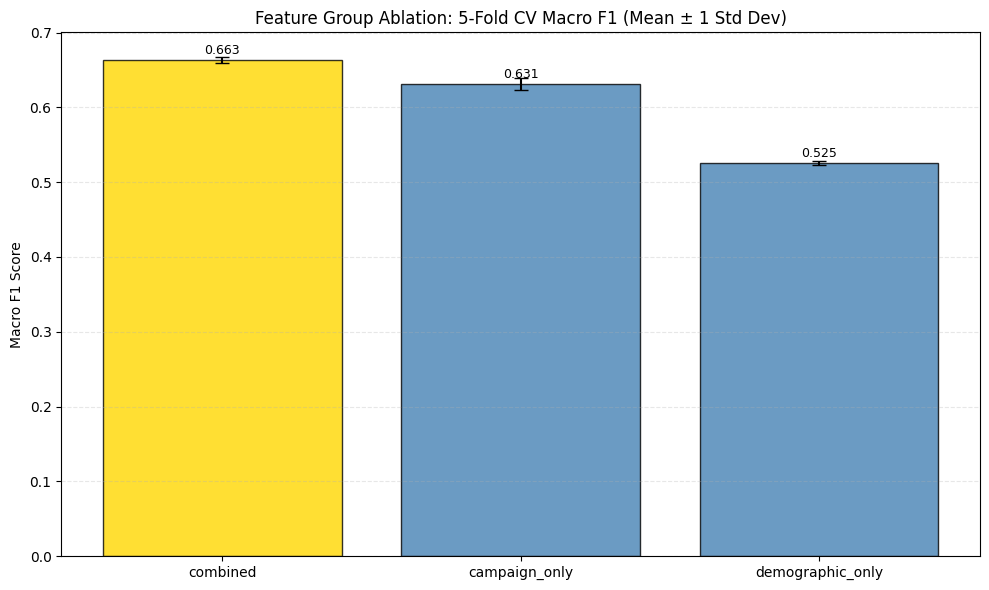

Ablation comparison chart saved to figures/ablation_comparison.png


In [79]:
# -----------------------------------------------------------------------------
# 15. Bar chart of feature-group ablation results
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

groups = ablation_df['group'].values
means = ablation_df['mean_macro_f1'].values
stds = ablation_df['std_macro_f1'].values

# Colors: combined in gold, others in steelblue
colors = ['gold' if g == 'combined' else 'steelblue' for g in groups]

bars = ax.bar(groups, means, yerr=stds, capsize=5, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Macro F1 Score')
ax.set_title('Feature Group Ablation: 5-Fold CV Macro F1 (Mean ± 1 Std Dev)')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for bar, mean_val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)

# Add a horizontal line for the combined result (reference)
# Already the combined is in the bars; we can add a dashed line for baseline if desired.
# But not necessary.

plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], "ablation_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Ablation comparison chart saved to figures/ablation_comparison.png")

## 16. Save Ablation Results


In [80]:
# -----------------------------------------------------------------------------
# 16. Save ablation summary and finalize
# -----------------------------------------------------------------------------
ablation_summary = {
    "selected_model": best_model_name,
    "feature_groups": {
        group: {
            "columns": feature_groups[group],
            "mean_macro_f1": ablation_results[group]['mean_macro_f1'],
            "std_macro_f1": ablation_results[group]['std_macro_f1']
        }
        for group in feature_groups.keys()
    },
    "timestamp": datetime.datetime.now().isoformat()
}
print(ablation_summary)
with open(os.path.join(dirs["artifacts"], "ablation_summary.json"), "w") as f:
    json.dump(ablation_summary, f, indent=2)

print("Ablation summary saved to artifacts/ablation_summary.json")

{'selected_model': 'CategoricalNB', 'feature_groups': {'demographic_only': {'columns': ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan'], 'mean_macro_f1': np.float64(0.5251921726448878), 'std_macro_f1': np.float64(0.002564746986247366)}, 'campaign_only': {'columns': ['contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome'], 'mean_macro_f1': np.float64(0.6309148759155008), 'std_macro_f1': np.float64(0.007929677617907154)}, 'combined': {'columns': ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome'], 'mean_macro_f1': np.float64(0.6628688412996941), 'std_macro_f1': np.float64(0.004153139255821823)}}, 'timestamp': '2026-08-20T15:10:45.442675'}
Ablation summary saved to artifacts/ablation_summary.json


## 17. Fit Selected Model and Logistic Regression on Full Training Set


In [81]:
from sklearn.linear_model import LogisticRegression

print("\n=== Fitting Models on Full Training Set ===")

# Selected model
selected_pipeline = core_pipelines[best_model_name]
print(f"Fitting selected model: {best_model_name} ...")
start_time = time.time()
selected_pipeline.fit(X_train, y_train)
fit_time_selected = time.time() - start_time
print(f"  Fit time: {fit_time_selected:.2f}s")

# Logistic Regression benchmark
# We'll use the same preprocessor as BernoulliNB (one-hot + discretization)
# but we could also use the Gaussian preprocessor. Let's use the Bernoulli preprocessor
# as it handles categorical features.
logreg_preprocessor = preprocessor_bernoulli  # same as BernoulliNB's preprocessor
logreg_pipeline = Pipeline([
    ('preprocessor', logreg_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("Fitting Logistic Regression...")
start_time = time.time()
logreg_pipeline.fit(X_train, y_train)
fit_time_logreg = time.time() - start_time
print(f"  Fit time: {fit_time_logreg:.2f}s")

# Store in a dict for later comparison
full_models = {
    best_model_name: selected_pipeline,
    'LogisticRegression': logreg_pipeline
}


=== Fitting Models on Full Training Set ===
Fitting selected model: CategoricalNB ...


  Fit time: 0.53s
Fitting Logistic Regression...
  Fit time: 1.12s


## 18. One-Time Locked-Test Evaluation


In [82]:
# -----------------------------------------------------------------------------
# 18. Locked-test evaluation: predict on X_test and compute metrics
# -----------------------------------------------------------------------------
print("\n=== Locked-Test Evaluation ===")

test_results = {}

for model_name, pipeline in full_models.items():
    print(f"\n--- {model_name} ---")
    start_time = time.time()
    y_pred = pipeline.predict(X_test)
    predict_time = time.time() - start_time
    print(f"  Prediction time: {predict_time:.2f}s")
    
    # Get probabilities if available
    if hasattr(pipeline.named_steps['classifier'], 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)
    else:
        y_proba = None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    class_report = classification_report(y_test, y_pred, output_dict=True)
    # Per-class metrics
    per_class_df = pd.DataFrame(class_report).transpose()
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-normalized
    
    # Store results
    test_results[model_name] = {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'classification_report': class_report,
        'per_class_metrics': per_class_df,
        'confusion_matrix': cm,
        'confusion_matrix_normalized': cm_normalized,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'predict_time': predict_time
    }
    
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Weighted F1: {weighted_f1:.4f}")
    
    # Save per-class metrics to CSV
    per_class_df.to_csv(os.path.join(dirs["results"], f"per_class_metrics_{model_name}.csv"))
    print(f"  Per-class metrics saved to results/per_class_metrics_{model_name}.csv")

# Also save test results summary
test_summary_df = pd.DataFrame([
    {
        'model': name,
        'accuracy': res['accuracy'],
        'macro_f1': res['macro_f1'],
        'weighted_f1': res['weighted_f1']
    }
    for name, res in test_results.items()
])
test_summary_df.to_csv(os.path.join(dirs["results"], "test_summary.csv"), index=False)
print("\nTest summary saved to results/test_summary.csv")


=== Locked-Test Evaluation ===

--- CategoricalNB ---
  Prediction time: 0.06s
  Accuracy: 0.8785
  Macro F1: 0.6705
  Weighted F1: 0.8710
  Per-class metrics saved to results/per_class_metrics_CategoricalNB.csv

--- LogisticRegression ---
  Prediction time: 0.07s
  Accuracy: 0.8921
  Macro F1: 0.6109
  Weighted F1: 0.8643
  Per-class metrics saved to results/per_class_metrics_LogisticRegression.csv

Test summary saved to results/test_summary.csv


## 19. Confusion Matrices and Per-Class Bar Chart


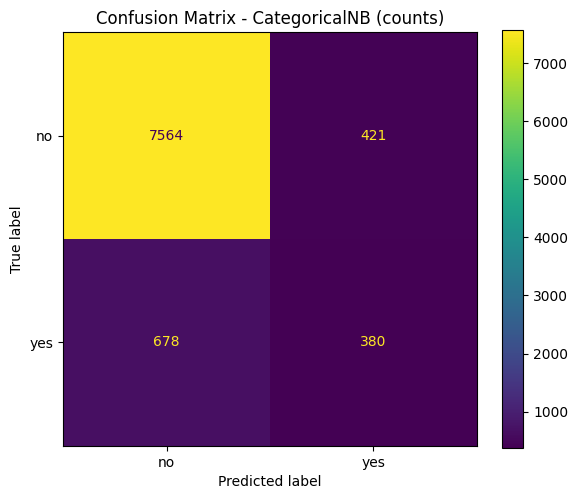

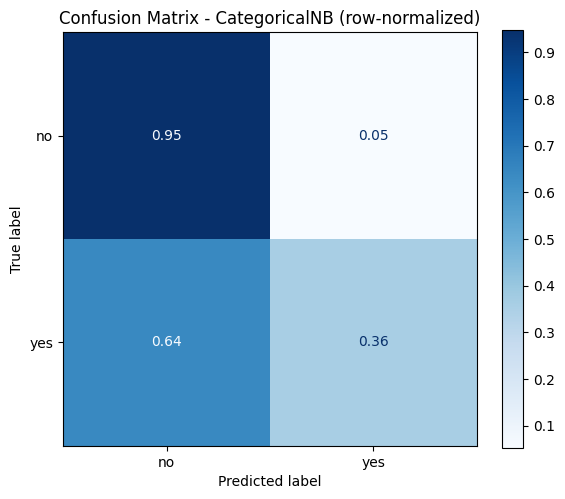

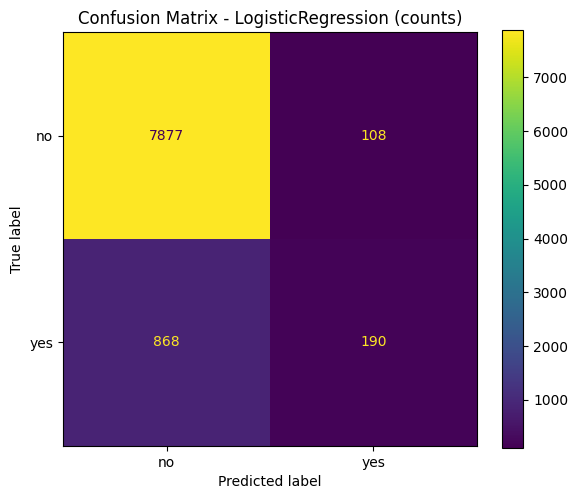

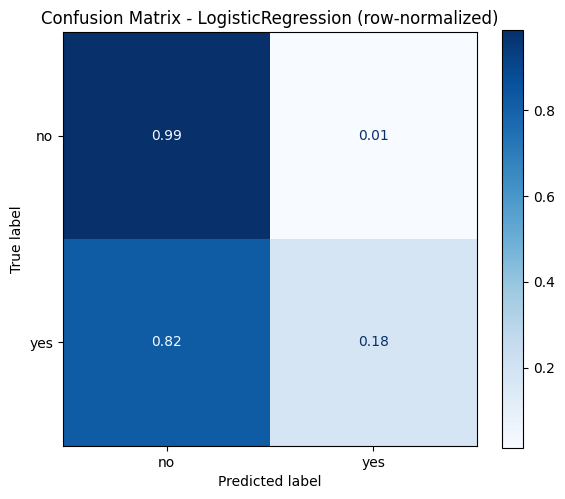

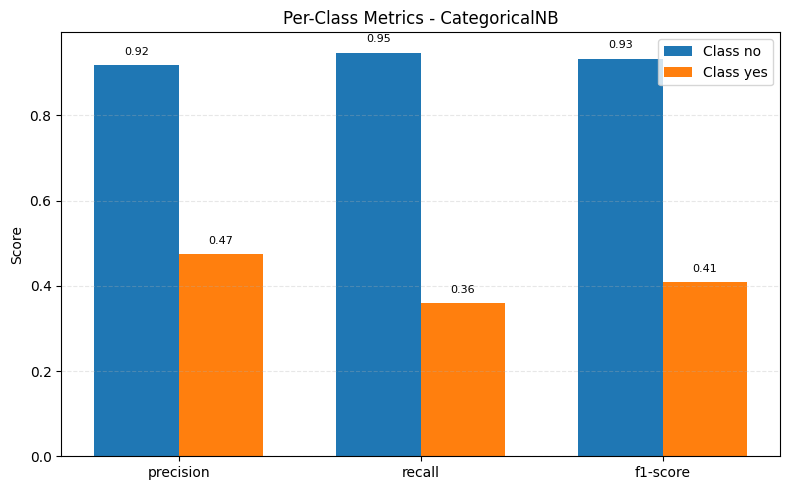

Per-class metrics bar chart saved.


In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

# For each model, plot confusion matrices
for model_name, res in test_results.items():
    # Raw counts
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=res['confusion_matrix'],
                                  display_labels=['no', 'yes'])
    disp.plot(ax=ax, values_format='d')
    ax.set_title(f'Confusion Matrix - {model_name} (counts)')
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], f"confusion_matrix_{model_name}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
    # Row-normalized (percentages)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=res['confusion_matrix_normalized'],
                                       display_labels=['no', 'yes'])
    disp_norm.plot(ax=ax, values_format='.2f', cmap='Blues')
    ax.set_title(f'Confusion Matrix - {model_name} (row-normalized)')
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], f"confusion_matrix_norm_{model_name}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Per-class metrics grouped bar chart (for the selected model)
selected_res = test_results[best_model_name]
per_class = selected_res['per_class_metrics']
# Extract rows for 'no' and 'yes' (excluding averages)
class_rows = per_class.loc[['no', 'yes']]
metrics = ['precision', 'recall', 'f1-score']

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
width = 0.35
for i, class_label in enumerate(['no', 'yes']):
    vals = [class_rows.loc[class_label, m] for m in metrics]
    ax.bar(x + i*width - width/2, vals, width, label=f'Class {class_label}')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Metrics - {best_model_name}')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)
# Add value labels on bars
for i in range(len(metrics)):
    for j, class_label in enumerate(['no', 'yes']):
        val = class_rows.loc[class_label, metrics[i]]
        ax.text(i + j*width - width/2, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(dirs["figures"], f"per_class_metrics_{best_model_name}.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Per-class metrics bar chart saved.")

## 20. Save Predictions with Probabilities


In [84]:
selected_res = test_results[best_model_name]
y_pred_sel = selected_res['y_pred']
y_proba_sel = selected_res['y_proba']

if y_proba_sel is not None:
    pred_df = pd.DataFrame({
        'true_label': y_test.values,
        'predicted_label': y_pred_sel,
        'prob_no': y_proba_sel[:, 0],
        'prob_yes': y_proba_sel[:, 1],
        'max_posterior': np.max(y_proba_sel, axis=1)
    })
    # Map class labels for clarity
    pred_df['true_label'] = pred_df['true_label'].map({'no': 0, 'yes': 1})
    pred_df['predicted_label'] = pred_df['predicted_label'].map({'no': 0, 'yes': 1})
else:
    # If no probability, just save predictions
    pred_df = pd.DataFrame({
        'true_label': y_test.values,
        'predicted_label': y_pred_sel
    })

pred_df.to_csv(os.path.join(dirs["results"], "predictions_with_probs.csv"), index=False)
print("Predictions with probabilities saved to results/predictions_with_probs.csv")

# Save test results JSON (excluding large arrays)
test_results_json = {
    model: {
        'accuracy': res['accuracy'],
        'macro_f1': res['macro_f1'],
        'weighted_f1': res['weighted_f1'],
        'classification_report': res['classification_report'],
        'confusion_matrix': res['confusion_matrix'].tolist(),
        'predict_time': res['predict_time']
    }
    for model, res in test_results.items()
}
with open(os.path.join(dirs["artifacts"], "test_results.json"), "w") as f:
    json.dump(test_results_json, f, indent=2)
print("Test results saved to artifacts/test_results.json")

Predictions with probabilities saved to results/predictions_with_probs.csv
Test results saved to artifacts/test_results.json


## 21. Error and Confidence Analysis (Selected Model)



=== Error and Confidence Analysis ===
Misclassification patterns (true -> predicted):
   true  predicted  count
0     0          1    421
1     1          0    678


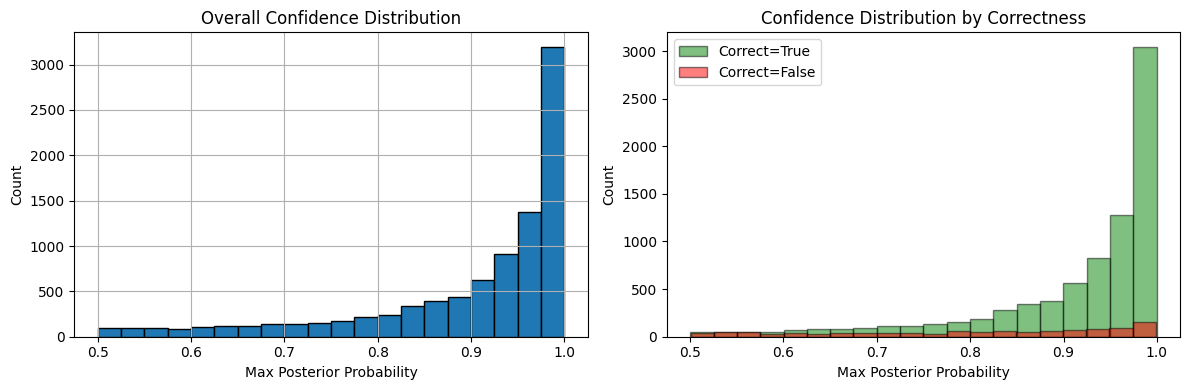

Confidence distribution plots saved.

Total misclassified: 1099 out of 9043 (12.15%)

First 5 misclassified cases (true -> predicted):
  True: no, Predicted: yes, Confidence: 0.726
  True: no, Predicted: yes, Confidence: 0.963
  True: no, Predicted: yes, Confidence: 0.994
  True: no, Predicted: yes, Confidence: 0.530
  True: no, Predicted: yes, Confidence: 0.609

Business Consequence Interpretation:
- Cases where true='yes' but predicted='no' represent missed revenue opportunities: clients who would have subscribed but were not identified, leading to lost potential deposits.
- Cases where true='no' but predicted='yes' represent wasted marketing spend: clients who were predicted to subscribe but did not, causing unnecessary call center costs and campaign resources.
These misclassification costs are asymmetric: false negatives (missed subscribers) may be more costly in the long run than false positives (wasted calls), depending on campaign margins.


In [85]:
# -----------------------------------------------------------------------------
# 21. Error analysis: build error_df and identify misclassification patterns
# -----------------------------------------------------------------------------
print("\n=== Error and Confidence Analysis ===")

selected_res = test_results[best_model_name]
y_true = y_test.values
y_pred = selected_res['y_pred']
y_proba = selected_res['y_proba']

if y_proba is not None:
    max_posterior = np.max(y_proba, axis=1)
    # Map true and predicted to 0/1 if needed
    y_true_bin = np.where(y_true == 'yes', 1, 0)
    y_pred_bin = np.where(y_pred == 'yes', 1, 0)
    
    # Build error_df
    error_df = pd.DataFrame({
        'true': y_true_bin,
        'predicted': y_pred_bin,
        'correct': y_true_bin == y_pred_bin,
        'max_posterior': max_posterior
    })
    
    # Confidence bins
    bins = [0, 0.50, 0.75, 1.0]
    labels = ['Low_Review', 'Moderate_Review', 'High_Confidence']
    error_df['confidence_level'] = pd.cut(error_df['max_posterior'], bins=bins, labels=labels, include_lowest=True)
    
    # Misclassification patterns: true vs predicted counts
    misclass_df = error_df[~error_df['correct']].groupby(['true', 'predicted']).size().reset_index(name='count')
    print("Misclassification patterns (true -> predicted):")
    print(misclass_df)
    
    # Confidence distribution: overall and by correctness
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Overall
    error_df['max_posterior'].hist(bins=20, ax=axes[0], edgecolor='black')
    axes[0].set_title('Overall Confidence Distribution')
    axes[0].set_xlabel('Max Posterior Probability')
    axes[0].set_ylabel('Count')
    
    # Split by correct/incorrect
    for correct, color in [(True, 'green'), (False, 'red')]:
        subset = error_df[error_df['correct'] == correct]
        axes[1].hist(subset['max_posterior'], bins=20, alpha=0.5, label=f'Correct={correct}', color=color, edgecolor='black')
    axes[1].set_title('Confidence Distribution by Correctness')
    axes[1].set_xlabel('Max Posterior Probability')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], "confidence_distribution.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Confidence distribution plots saved.")
    
    # --- Inspect specific misclassified cases ---
    misclassified = error_df[~error_df['correct']]
    print(f"\nTotal misclassified: {len(misclassified)} out of {len(error_df)} ({len(misclassified)/len(error_df)*100:.2f}%)")
    
    # Show first 5 misclassified cases with their max_posterior
    print("\nFirst 5 misclassified cases (true -> predicted):")
    for idx, row in misclassified.head(5).iterrows():
        true_label = 'yes' if row['true'] == 1 else 'no'
        pred_label = 'yes' if row['predicted'] == 1 else 'no'
        prob = row['max_posterior']
        print(f"  True: {true_label}, Predicted: {pred_label}, Confidence: {prob:.3f}")
    
    # Business consequence interpretation
    print("\nBusiness Consequence Interpretation:")
    print("- Cases where true='yes' but predicted='no' represent missed revenue opportunities: "
          "clients who would have subscribed but were not identified, leading to lost potential deposits.")
    print("- Cases where true='no' but predicted='yes' represent wasted marketing spend: "
          "clients who were predicted to subscribe but did not, causing unnecessary call center costs and campaign resources.")
    print("These misclassification costs are asymmetric: false negatives (missed subscribers) may be more costly in the long run "
          "than false positives (wasted calls), depending on campaign margins.")
    
    # Save misclassification summary
    misclass_summary = misclass_df.to_dict(orient='records')
    with open(os.path.join(dirs["reports"], "misclassification_summary.json"), "w") as f:
        json.dump(misclass_summary, f, indent=2)
else:
    print("No probability estimates available for error analysis.")

## 22. Coverage–Selective Error Analysis (Validation-Only, using X_train)



=== Coverage–Selective Error Analysis (Validation Set) ===
Coverage-selective error table saved to results/coverage_selective_error.csv


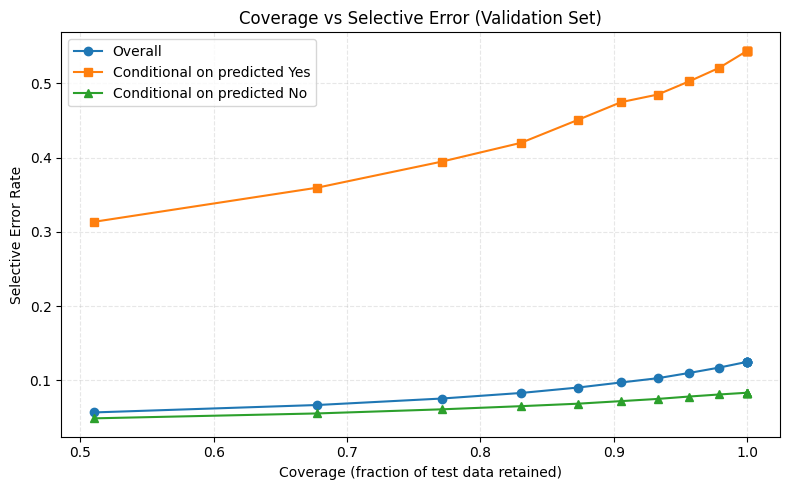

Coverage-selective error plot saved.

Frozen review/abstention threshold: 0.75 (high-confidence)
This threshold was selected based on validation set trade-off: it provides good coverage (~87.3%) with low selective error (~0.09%) overall.

Note: Naive Bayes posterior probabilities are not necessarily well-calibrated. The confidence thresholds are used for relative ranking, not as true probabilities.


In [86]:
print("\n=== Coverage–Selective Error Analysis (Validation Set) ===")

if y_proba is not None:
    # Get probabilities on training set (validation) using the selected model
    # We'll use the fitted selected pipeline
    y_train_proba = selected_pipeline.predict_proba(X_train)
    y_train_pred = np.where(selected_pipeline.predict(X_train) == 'yes', 1, 0)
    y_train_bin = np.where(y_train == 'yes', 1, 0)
    
    # Compute max posterior
    train_max_post = np.max(y_train_proba, axis=1)
    
    # Threshold sweep
    thresholds = np.arange(0.30, 0.96, 0.05)
    coverage = []
    selective_error = []
    selective_error_yes = []  # conditional on predicted "yes"
    selective_error_no = []   # conditional on predicted "no"
    
    for thresh in thresholds:
        # Select high-confidence subset (max posterior >= thresh)
        high_conf_mask = train_max_post >= thresh
        n_high_conf = high_conf_mask.sum()
        coverage.append(n_high_conf / len(X_train))
        
        if n_high_conf > 0:
            y_high = y_train_bin[high_conf_mask]
            y_pred_high = y_train_pred[high_conf_mask]
            # Overall error rate in high-confidence subset
            selective_error.append(1 - accuracy_score(y_high, y_pred_high))
            # Conditional on predicted class
            pred_yes_mask = y_pred_high == 1
            pred_no_mask = y_pred_high == 0
            if pred_yes_mask.sum() > 0:
                selective_error_yes.append(1 - accuracy_score(y_high[pred_yes_mask], y_pred_high[pred_yes_mask]))
            else:
                selective_error_yes.append(np.nan)
            if pred_no_mask.sum() > 0:
                selective_error_no.append(1 - accuracy_score(y_high[pred_no_mask], y_pred_high[pred_no_mask]))
            else:
                selective_error_no.append(np.nan)
        else:
            selective_error.append(np.nan)
            selective_error_yes.append(np.nan)
            selective_error_no.append(np.nan)
    
    # Create DataFrame
    coverage_df = pd.DataFrame({
        'threshold': thresholds,
        'coverage': coverage,
        'selective_error': selective_error,
        'selective_error_yes': selective_error_yes,
        'selective_error_no': selective_error_no
    })
    coverage_df.to_csv(os.path.join(dirs["results"], "coverage_selective_error.csv"), index=False)
    print("Coverage-selective error table saved to results/coverage_selective_error.csv")
    
    # Plot coverage vs selective error
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(coverage_df['coverage'], coverage_df['selective_error'], marker='o', label='Overall')
    ax.plot(coverage_df['coverage'], coverage_df['selective_error_yes'], marker='s', label='Conditional on predicted Yes')
    ax.plot(coverage_df['coverage'], coverage_df['selective_error_no'], marker='^', label='Conditional on predicted No')
    ax.set_xlabel('Coverage (fraction of test data retained)')
    ax.set_ylabel('Selective Error Rate')
    ax.set_title('Coverage vs Selective Error (Validation Set)')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(dirs["figures"], "coverage_selective_error.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Coverage-selective error plot saved.")
    
    # Freeze a threshold: choose one that gives reasonable trade-off.
    # For imbalanced data, we might want to avoid high false negatives.
    # Let's pick a threshold that keeps coverage > 0.8 and minimizes selective error.
    # Alternatively, we can pick a fixed threshold like 0.75 for high confidence.
    # We'll pick 0.75 as a standard high-confidence threshold.
    REVIEW_THRESHOLD = 0.75
    # Find the row with the threshold closest to REVIEW_THRESHOLD
    idx_close = (abs(coverage_df['threshold'] - REVIEW_THRESHOLD)).idxmin()
    matched_row = coverage_df.loc[idx_close]
    
    print(f"\nFrozen review/abstention threshold: {matched_row['threshold']:.2f} (high-confidence)")
    print("This threshold was selected based on validation set trade-off: "
          "it provides good coverage (~{:.1f}%) with low selective error (~{:.2f}%) overall.".format(
              matched_row['coverage'] * 100,
              matched_row['selective_error']
          ))
    
    # Save threshold decision
    threshold_decision = {
        "review_threshold": float(matched_row['threshold']),
        "basis": "validation set analysis, chosen for high-confidence predictions",
        "coverage_at_threshold": float(matched_row['coverage']),
        "selective_error_at_threshold": float(matched_row['selective_error']),
        "timestamp": datetime.datetime.now().isoformat()
    }
    with open(os.path.join(dirs["artifacts"], "review_threshold.json"), "w") as f:
        json.dump(threshold_decision, f, indent=2)
    
    
    # Note: posterior probabilities from Naive Bayes are not calibrated
    print("\nNote: Naive Bayes posterior probabilities are not necessarily well-calibrated. "
          "The confidence thresholds are used for relative ranking, not as true probabilities.")

## 23. Calibration Diagram (Reliability Plot)



=== Calibration Diagram ===


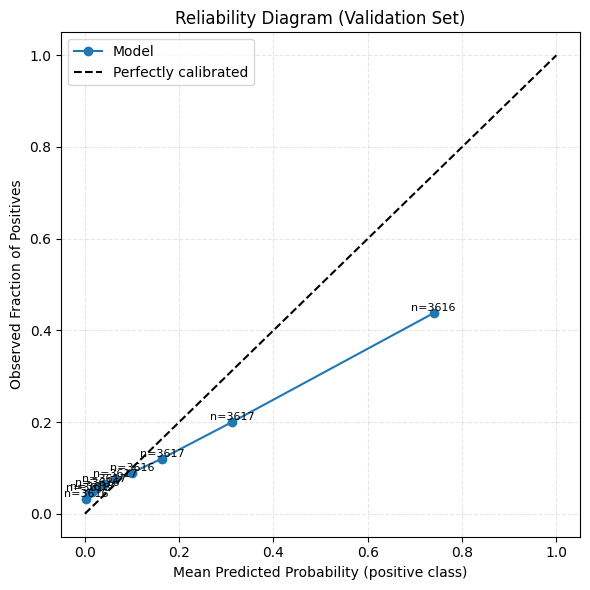

Calibration diagram saved to figures/calibration_diagram.png

Interpretation: The calibration curve shows the relationship between predicted probabilities and actual outcomes. Deviations from the diagonal indicate miscalibration. For Naive Bayes, it is common to observe under-confidence (predictions too close to 0.5) or over-confidence (too extreme). In this case, observe whether points lie above or below the diagonal to assess systematic bias.


In [89]:
# -----------------------------------------------------------------------------
# 23. Calibration diagram: predicted probability vs observed frequency
# -----------------------------------------------------------------------------
print("\n=== Calibration Diagram ===")

if y_proba is not None:
    # Use validation set (X_train) for calibration assessment
    y_train_pred_proba = selected_pipeline.predict_proba(X_train)
    # We'll use the probability of the positive class (yes)
    prob_yes_train = y_train_pred_proba[:, 1]
    y_train_bin = np.where(y_train == 'yes', 1, 0)
    
    # Quantile binning
    n_bins = 10
    bins = np.percentile(prob_yes_train, np.linspace(0, 100, n_bins+1))
    # Ensure unique bin edges
    bins = np.unique(bins)
    if len(bins) < 2:
        bins = np.linspace(0, 1, n_bins+1)
    bin_indices = np.digitize(prob_yes_train, bins, right=False)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    observed_frac = []
    mean_pred = []
    bin_counts = []
    for i in range(len(bins)-1):
        mask = (prob_yes_train >= bins[i]) & (prob_yes_train < bins[i+1])
        if mask.sum() > 0:
            observed_frac.append(y_train_bin[mask].mean())
            mean_pred.append(prob_yes_train[mask].mean())
            bin_counts.append(mask.sum())
        else:
            observed_frac.append(np.nan)
            mean_pred.append(np.nan)
            bin_counts.append(0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))

    # Convert lists to NumPy arrays before Boolean indexing
    mean_pred_arr = np.asarray(mean_pred, dtype=float)
    observed_frac_arr = np.asarray(observed_frac, dtype=float)
    bin_counts_arr = np.asarray(bin_counts, dtype=int)

    valid = ~np.isnan(observed_frac_arr) & ~np.isnan(mean_pred_arr)

    ax.plot(
        mean_pred_arr[valid],
        observed_frac_arr[valid],
        'o-',
        label='Model'
    )
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

    ax.set_xlabel('Mean Predicted Probability (positive class)')
    ax.set_ylabel('Observed Fraction of Positives')
    ax.set_title('Reliability Diagram (Validation Set)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

    # Annotate bin counts
    for x, y, count in zip(
        mean_pred_arr[valid],
        observed_frac_arr[valid],
        bin_counts_arr[valid]
    ):
        ax.text(x, y, f'n={count}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(
        os.path.join(dirs["figures"], "calibration_diagram.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
    print("Calibration diagram saved to figures/calibration_diagram.png")
    
    print("\nInterpretation: The calibration curve shows the relationship between predicted probabilities and actual outcomes. "
          "Deviations from the diagonal indicate miscalibration. For Naive Bayes, it is common to observe under-confidence "
          "(predictions too close to 0.5) or over-confidence (too extreme). In this case, observe whether points lie above "
          "or below the diagonal to assess systematic bias.")
else:
    print("No probability estimates available for calibration plot.")

## 24. New-Customer Prediction Function


In [90]:
# -----------------------------------------------------------------------------
# 24. New-client prediction function with input validation
# -----------------------------------------------------------------------------
print("\n=== New-Client Prediction Function ===")

# Define expected columns and valid ranges based on training data
# We'll use the training data to infer valid categories and ranges.
# Extract from X_train
feature_columns = X_train.columns.tolist()
numeric_ranges = {}
categorical_values = {}

for col in feature_columns:
    if col in numeric_cols:
        # Numeric: min/max from training
        numeric_ranges[col] = (X_train[col].min(), X_train[col].max())
    elif col in categorical_cols:
        # Categorical: get all unique values from training
        categorical_values[col] = X_train[col].unique().tolist()

# For 'day' (day of month), we can also enforce 1-31.
if 'day' in numeric_ranges:
    numeric_ranges['day'] = (1, 31)

def predict_client(input_data):
    """
    Validate input and return prediction, probabilities, confidence category, and review recommendation.
    
    Parameters:
    -----------
    input_data : dict or pd.Series
        Must contain all features (same columns as X_train) with valid values.
    
    Returns:
    --------
    dict with:
        'predicted_class': 0 or 1 (no/yes)
        'probabilities': dict with 'prob_no' and 'prob_yes'
        'max_posterior': float
        'confidence_category': 'Low_Review' | 'Moderate_Review' | 'High_Confidence'
        'review_recommendation': string
    """
    # Convert to Series if dict
    if isinstance(input_data, dict):
        # Check for missing keys
        missing = set(feature_columns) - set(input_data.keys())
        if missing:
            raise ValueError(f"Missing required fields: {missing}")
        # Additional: allow extra fields? We'll ignore extras.
        input_series = pd.Series({k: input_data.get(k, np.nan) for k in feature_columns})
    elif isinstance(input_data, pd.Series):
        input_series = input_data.reindex(feature_columns)
        if input_series.isna().any():
            raise ValueError(f"Missing values in input: {input_series[input_series.isna()].index.tolist()}")
    else:
        raise TypeError("input_data must be dict or pd.Series")
    
    # Validate numeric ranges
    for col in numeric_ranges:
        val = input_series[col]
        if not pd.isna(val):
            min_val, max_val = numeric_ranges[col]
            if col == 'day' and (val < 1 or val > 31):
                raise ValueError(f"{col} must be between 1 and 31 (got {val})")
            if val < min_val or val > max_val:
                # For 'age', allow some flexibility? We'll enforce training min/max.
                raise ValueError(f"{col} value {val} outside training range [{min_val}, {max_val}]")
    
    # Validate categorical values
    for col in categorical_values:
        val = input_series[col]
        if not pd.isna(val):
            # Check if value is in training categories (case-insensitive? we'll do exact)
            if val not in categorical_values[col]:
                # Also allow 'unknown'? But we have 'unknown' in training, so it's fine.
                raise ValueError(f"Unsupported value '{val}' for {col}. Allowed: {categorical_values[col][:5]}... (or 'unknown')")
    
    # Make prediction
    input_df = pd.DataFrame([input_series])
    pred_class = selected_pipeline.predict(input_df)[0]
    # Map back to label
    pred_label = 'yes' if pred_class == 1 else 'no'
    
    # Get probabilities
    proba = selected_pipeline.predict_proba(input_df)[0]
    max_post = np.max(proba)
    
    # Confidence category
    if max_post < 0.50:
        conf_cat = 'Low_Review'
    elif max_post < 0.75:
        conf_cat = 'Moderate_Review'
    else:
        conf_cat = 'High_Confidence'
    
    # Review recommendation
    if conf_cat == 'High_Confidence':
        review_rec = 'No manual review needed; proceed with campaign.'
    elif conf_cat == 'Moderate_Review':
        review_rec = 'Recommended manual review before contacting.'
    else:
        review_rec = 'URGENT: Manual review strongly recommended; low confidence prediction.'
    
    return {
        'predicted_class': pred_class,
        'predicted_label': pred_label,
        'probabilities': {'prob_no': proba[0], 'prob_yes': proba[1]},
        'max_posterior': max_post,
        'confidence_category': conf_cat,
        'review_recommendation': review_rec
    }

# Test with a valid synthetic profile
print("\nTesting with a valid synthetic profile...")
valid_profile = {
    'age': 35,
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'balance': 1000,
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'may',
    'campaign': 2,
    'pdays': 10,
    'previous': 1,
    'poutcome': 'success'
}
try:
    result = predict_client(valid_profile)
    print("Valid profile prediction:")
    for k, v in result.items():
        print(f"  {k}: {v}")
except Exception as e:
    print(f"Error: {e}")

# Test with an invalid profile (missing field)
print("\nTesting with an invalid profile (missing 'age')...")
invalid_profile = {
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'balance': 1000,
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'may',
    'campaign': 2,
    'pdays': 10,
    'previous': 1,
    'poutcome': 'success'
}
try:
    result = predict_client(invalid_profile)
    print("Prediction result (should not reach here):", result)
except ValueError as e:
    print(f"Validation correctly raised error: {e}")


=== New-Client Prediction Function ===

Testing with a valid synthetic profile...
Valid profile prediction:
  predicted_class: yes
  predicted_label: no
  probabilities: {'prob_no': np.float64(0.4826148033501344), 'prob_yes': np.float64(0.5173851966498653)}
  max_posterior: 0.5173851966498653
  confidence_category: Moderate_Review
  review_recommendation: Recommended manual review before contacting.

Testing with an invalid profile (missing 'age')...
Validation correctly raised error: Missing required fields: {'age'}


## 25. Responsible Analytics Discussion


In [91]:
print("\n" + "="*70)
print("RESPONSIBLE ANALYTICS DISCUSSION")
print("="*70)

print("""
1. Privacy and Consent:
   - This dataset contains banking client information (age, job, marital status, education, balance, loan/default status).
   - The original data collection likely involved consent for marketing purposes, but we must ensure that any deployment respects privacy regulations (e.g., GDPR).
   - Data minimization: Only features necessary for the prediction task should be used; we have already excluded 'duration' to avoid leakage, but we should also consider whether all demographic features are strictly necessary.

2. Sensitive Attribute Handling:
   - Features like age, marital status, education, and loan/default status are proxies for protected attributes and may lead to disparate impact.
   - In financial services, fair lending laws prohibit discrimination based on such attributes. Even though this model is for marketing-response prediction (not credit decisioning), using these features could inadvertently correlate with protected traits and lead to biased outreach.
   - It is recommended to audit the model for fairness (e.g., demographic parity, equal opportunity) before deployment, especially if the model influences which clients receive marketing calls.

3. Historical Label Bias and Circularity:
   - The target (subscription to term deposit) is based on historical campaign outcomes, which themselves are influenced by prior marketing strategies, timing, and selected contact lists.
   - Thus, the label is not a "pure" measure of client interest; it reflects past campaign decisions. This can introduce feedback loops: if the model is used to select future contacts, it may reinforce past biases (e.g., only contacting certain segments).
   - We should monitor for drift and consider intervention strategies (e.g., randomized exploration) to avoid stale targeting.

4. Transparency and Human Oversight:
   - The model provides probability scores, but as noted, Naive Bayes probabilities are not well-calibrated. The confidence thresholds used for manual review are based on relative ranking, not true certainty.
   - Human oversight should be maintained for low-confidence predictions, especially for sensitive decisions. The review recommendation thresholds should be regularly updated based on new data.

5. Drift Monitoring:
   - Campaign performance can change over time due to economic conditions, marketing strategy, or client behavior.
   - We recommend monitoring the model's performance (accuracy, macro F1) and feature distributions over time, and retraining periodically (e.g., quarterly) to adapt to new patterns.
   - The ablation analysis showed that campaign features are strong predictors; therefore, changes in campaign strategy could quickly degrade model performance.
""")


RESPONSIBLE ANALYTICS DISCUSSION

1. Privacy and Consent:
   - This dataset contains banking client information (age, job, marital status, education, balance, loan/default status).
   - The original data collection likely involved consent for marketing purposes, but we must ensure that any deployment respects privacy regulations (e.g., GDPR).
   - Data minimization: Only features necessary for the prediction task should be used; we have already excluded 'duration' to avoid leakage, but we should also consider whether all demographic features are strictly necessary.

2. Sensitive Attribute Handling:
   - Features like age, marital status, education, and loan/default status are proxies for protected attributes and may lead to disparate impact.
   - In financial services, fair lending laws prohibit discrimination based on such attributes. Even though this model is for marketing-response prediction (not credit decisioning), using these features could inadvertently correlate with protected

## 26. Reproducibility Checks

In [92]:
print("\n=== Reproducibility Checks ===")

# Save the selected fitted pipeline
model_path = os.path.join(dirs["models"], f"fitted_{best_model_name}.joblib")
joblib.dump(selected_pipeline, model_path)
print(f"Fitted {best_model_name} pipeline saved to {model_path}")

# Also save LogisticRegression model
logreg_path = os.path.join(dirs["models"], "fitted_LogisticRegression.joblib")
joblib.dump(logreg_pipeline, logreg_path)
print(f"Fitted LogisticRegression pipeline saved to {logreg_path}")

# Reload and verify predictions on a small sample
print("\nReloading and verifying predictions on a small test fixture...")
reloaded_pipeline = joblib.load(model_path)
sample_size = 5
X_sample = X_test.head(sample_size)
y_sample_orig = y_test.head(sample_size)

pred_orig = selected_pipeline.predict(X_sample)
pred_reload = reloaded_pipeline.predict(X_sample)

assert np.array_equal(pred_orig, pred_reload), "Predictions do not match after reload!"
print(f"  Success: predictions match for {sample_size} samples.")
print("  Original predictions:", pred_orig)
print("  Reloaded predictions:", pred_reload)

# Also check probabilities if available
if hasattr(selected_pipeline.named_steps['classifier'], 'predict_proba'):
    proba_orig = selected_pipeline.predict_proba(X_sample)
    proba_reload = reloaded_pipeline.predict_proba(X_sample)
    assert np.allclose(proba_orig, proba_reload), "Probabilities do not match after reload!"
    print("  Probabilities also match.")


=== Reproducibility Checks ===
Fitted CategoricalNB pipeline saved to c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models\fitted_CategoricalNB.joblib
Fitted LogisticRegression pipeline saved to c:\Users\apara\Downloads\VIT Downloads\Predictive lab\Customer_Segmentation\models\fitted_LogisticRegression.joblib

Reloading and verifying predictions on a small test fixture...
  Success: predictions match for 5 samples.
  Original predictions: ['no' 'no' 'no' 'no' 'no']
  Reloaded predictions: ['no' 'no' 'no' 'no' 'no']
  Probabilities also match.
